# Orientation and direction selectivity (OSI / DSI) in V1 — BTBR vs C57BL/6J
**Passive stimulation → Responsive neurons → Tuning curve → OSI / DSI → Genotype comparison**

---
### Expected folder structure
```
Calcio/
├── BTBR_V1/                  ← group folder name defines genotype
│   ├── animal_date/
│   │   ├── *reg*.txt         ← microscope log
│   │   ├── *pas*.txt         ← stimulus log (PsychoPy)
│   │   └── *traces*.csv      ← fluorescence traces
│   └── ...
└── C57_V1/
    └── ...
```
> ✎ *To write: one paragraph on the question this notebook answers (are V1 neurons less orientation-selective in BTBR?) and what the notebook does NOT do (noise correlations, cosine similarity, ensembles live elsewhere).*

## 1. Which paths, timing and thresholds does the analysis assume?
> ✎ *To write: which values are confirmed by the acquisition and which are working assumptions.*

In [1]:
# ─── PATHS ────────────────────────────────────────────────────────────────────
from pathlib import Path

DATA_ROOT = r'D:\AL-205\Nicole\Calcio\Nueva_carpeta'  # <── change this

# Keywords used to find files (case-insensitive substring of the file name)
SCOPE_KEYWORD  = 'reg'     # microscope TXT
STIM_KEYWORD   = 'pas'     # stimulus TXT
TRACES_KEYWORD = 'traces'  # fluorescence traces CSV

# Group folder → genotype
GENOTYPE_FOLDERS = {
    'BTBR': 'BTBR',
    'C57':  'C57',
}

# ─── ACQUISITION ──────────────────────────────────────────────────────────────
SAMPLING_RATE = 5                       # Hz
MS_PER_FRAME  = 1000 / SAMPLING_RATE    # 200 ms (nominal, not measured)

# ─── TRIAL WINDOW ─────────────────────────────────────────────────────────────
SEC_BEFORE    = 2
SEC_AFTER     = 4
FRAMES_BEFORE = int(SEC_BEFORE * SAMPLING_RATE)   # 10
FRAMES_AFTER  = int(SEC_AFTER  * SAMPLING_RATE)   # 20
TOTAL_FRAMES  = FRAMES_BEFORE + FRAMES_AFTER      # 30

# Response window (frames within the trial, 0 = trial start)
RESP_START = FRAMES_BEFORE      # frame 10 = stimulus onset
RESP_END   = TOTAL_FRAMES       # frame 30

# ─── THRESHOLDS ───────────────────────────────────────────────────────────────
RESPONSIVE_STD = 3     # SDs above baseline for a responsive neuron   # TODO: cite
OSI_THRESH     = 0.7   # minimum OSI for a selective neuron           # TODO: cite

# ─── OUTPUT ───────────────────────────────────────────────────────────────────
# Keep the 'pipeline_output' prefix: discover_animals() skips folders that start
# with it. Any other name is read as a genotype group and raises ValueError.
OUTPUT_DIR = Path(DATA_ROOT) / 'pipeline_output_osi_dsi'
OUTPUT_DIR.mkdir(exist_ok=True)

print('Config loaded.')
print(f'Output → {OUTPUT_DIR}')

Config loaded.
Output → D:\AL-205\Nicole\Calcio\Nueva_carpeta\pipeline_output_osi_dsi


## 2. Which animals are in the dataset, and what genotype is each?
> ✎ *To write: why genotype comes from the group folder name and why an unmatched folder must fail loudly instead of defaulting.*

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
#  File detection
# ══════════════════════════════════════════════════════════════════════════════

def find_file(folder: Path, keyword: str) -> Path:
    """
    Finds exactly one file in `folder` whose name contains `keyword` (case-insensitive).
    - SCOPE_KEYWORD / STIM_KEYWORD: only .txt files are considered.
      ('pas' also matches 'pasiva' in CSVs, .lsm, .tif and 'pas_vid' in .avi files.)
    - Any other keyword: if several match, .csv files are preferred.
    Raises FileNotFoundError if none is found and ValueError if it is still ambiguous.
    """
    kw = keyword.lower()
    matches = [f for f in folder.iterdir()
               if f.is_file() and kw in f.name.lower()]

    if kw in (SCOPE_KEYWORD.lower(), STIM_KEYWORD.lower()):
        matches = [f for f in matches if f.suffix.lower() == '.txt']
    elif len(matches) > 1:
        matches = [f for f in matches if f.suffix.lower() == '.csv'] or matches

    if not matches:
        raise FileNotFoundError(f"No file with '{keyword}' found in {folder}")
    if len(matches) > 1:
        raise ValueError(
            f"{len(matches)} candidates for '{keyword}' in {folder.name}: "
            f"{[f.name for f in matches]}")
    return matches[0]


def detect_genotype(group_name: str) -> str:
    for kw, geno in GENOTYPE_FOLDERS.items():
        if kw.upper() in group_name.upper():
            return geno
    raise ValueError(f"'{group_name}' does not match any genotype in GENOTYPE_FOLDERS")


def discover_animals(root: str) -> list:
    """Walks two levels: group/animal. Skips output folders by prefix."""
    EXCLUDE_PREFIXES = ('pipeline_output', 'rastermap_output')

    root = Path(root)
    animals = []
    for group in sorted(root.iterdir()):
        if not group.is_dir() or group.name.startswith('.') \
                or group.name.startswith(EXCLUDE_PREFIXES):
            continue
        genotype = detect_genotype(group.name)   # raises ValueError if unmatched
        for animal in sorted(group.iterdir()):
            if not animal.is_dir() or animal.name.startswith('.'):
                continue
            animals.append({
                'animal_id': animal.name,
                'genotype':  genotype,
                'group':     group.name,
                'folder':    animal,
            })
    if not animals:
        raise RuntimeError(f'No animals found under {root}')
    return animals


animals = discover_animals(DATA_ROOT)
print(f'Animals found: {len(animals)}')
for a in animals:
    print(f"  [{a['genotype']:6}]  {a['group']}/{a['animal_id']}")

Animals found: 11
  [BTBR  ]  BTBR/BTBR_R2_060725
  [BTBR  ]  BTBR/BTBR_R2_270923_hembra_pasiva_Isaac
  [BTBR  ]  BTBR/BTBRL1030825_Reg_12_12_25
  [BTBR  ]  BTBR/BTBRR1_280825_Reg_15_12_25
  [C57   ]  C57/C57_SM_Isaac
  [C57   ]  C57/C57L10300325_pasiva
  [C57   ]  C57/C57L2_Isaac
  [C57   ]  C57/C57R1230825_Reg_15_12_25
  [C57   ]  C57/C57R20010525_pasiva
  [C57   ]  C57/C57R3230825_Reg_15_12_25
  [C57   ]  C57/Delta 4-22 wt


## 3. How is each stimulus onset mapped to an imaging frame?
> ✎ *To write: which clock defines frame times, what the sensor flags mean (23 = frame, 4 = stimulus onset), and why timestamps are matched to the second before the flag is located.*

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
#  TXT parsers
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np

def parse_scope_txt(filepath: Path) -> tuple:
    """Parses the microscope TXT.
    Format: HH:MM:SS.microsec.frameN.flag.channel
    Returns timestamp_strs, millisec (normalised to t=0), sensores."""
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    datasplit = [l.strip().split('.') for l in lines[1:]]
    datasplit = [d for d in datasplit if len(d) >= 4]
    timestamp_strs = [d[0] for d in datasplit]
    millisec  = np.array([float(d[2]) for d in datasplit])
    sensores  = np.array([float(d[3]) for d in datasplit])
    millisec  = millisec - millisec[0]
    return timestamp_strs, millisec, sensores


def parse_stim_txt(filepath: Path) -> tuple:
    """Parses the stimulus TXT.
    Format: HH:MM:SS.mmm.FLAG
      11   → stimulus start
      0XXX → angle, logged when the stimulus ends (4 s later)
    Returns tstamp_stlog, estimulos."""
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
    datasplit    = [l.strip().split('.') for l in lines]
    datasplit    = [d for d in datasplit if len(d) >= 3]
    tstamp_stlog = [d[0] for d in datasplit]
    estimulos    = np.array([float(d[2]) for d in datasplit])
    return tstamp_stlog, estimulos


def get_clean_frame_times(millisec: np.ndarray, sensores: np.ndarray,
                           min_interval_ms: float = 100.0) -> np.ndarray:
    """Extracts real frame times (flag == 23), dropping duplicates."""
    framt    = np.where(sensores == 23)[0]
    t_fram   = millisec[framt]
    ll       = np.diff(t_fram)
    idx_keep = np.where(ll > min_interval_ms)[0] + 1
    return np.insert(t_fram[idx_keep], 0, t_fram[0])


# ══════════════════════════════════════════════════════════════════════════════
#  Stimulus ↔ frame alignment
# ══════════════════════════════════════════════════════════════════════════════

def align_stimuli_to_frames(timestamp_strs, millisec, sensores,
                             tstamp_stlog, estimulos,
                             ms_per_frame: float = 200.0) -> np.ndarray:
    """Returns stimsnframes (n_angles, n_trials, 2):
       [:,:,0] = angle, [:,:,1] = onset frame."""
    t_fram_clean = get_clean_frame_times(millisec, sensores)
    max_frame    = len(t_fram_clean) - 1

    stims_all, stim_counts = np.unique(estimulos, return_counts=True)
    stims    = stims_all[stims_all != 11]
    n_trials = int(stim_counts[stims_all == 11][0]) if 11 in stims_all else \
               int(np.min(stim_counts[stims_all != 11]))

    idx_t_stim = np.zeros((n_trials, len(stims)))

    ts_arr = np.array(timestamp_strs)
    for s, stim in enumerate(stims):
        t_stamp_idx = np.where(estimulos == stim)[0]
        t_stamp     = [tstamp_stlog[i - 1] for i in t_stamp_idx]
        for j, ts in enumerate(t_stamp):
            if j >= n_trials:
                break
            hms = list(map(int, ts.split(':')))
            hms[2] += 1
            ts2 = f"{hms[0]:02}:{hms[1]:02}:{hms[2]:02}"
            idx_bin = np.concatenate((
                np.where(ts_arr == ts)[0],
                np.where(ts_arr == ts2)[0]
            ))
            if len(idx_bin) > 0:
                idx_stim_j = np.where(
                    sensores[idx_bin[0]:idx_bin[-1]] == 4
                )[0] + idx_bin[0]
                if len(idx_stim_j) > 0:
                    idx_t_stim[j, s] = idx_stim_j[0]

    t_Stim_ms   = millisec[idx_t_stim.astype(int)]
    tf          = np.round(t_Stim_ms / ms_per_frame).astype(int)
    tf_clamped  = np.clip(tf, 0, max_frame)
    a           = t_Stim_ms - t_fram_clean[tf_clamped] > ms_per_frame
    tf[a]      += 1
    tf          = np.clip(tf, 0, max_frame).T  # (n_angles, n_trials)

    stims_tiled  = np.tile(stims[:, np.newaxis], (1, tf.shape[1]))
    stimsnframes = np.stack([stims_tiled, tf], axis=2)
    return stimsnframes

## 4. How is a trial's response extracted and normalized?
> ✎ *To write: what F0 is (median of the pre-stimulus frames, per trial and per neuron), what happens when a window runs past the recording edge, and what NaN → 0 does to F0.*

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  Aligned signal extraction
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd

def extract_aligned_signals(traces_csv: Path, stimsnframes: np.ndarray,
                             frames_before: int = FRAMES_BEFORE,
                             frames_after:  int = FRAMES_AFTER) -> dict:
    """Returns extracted_data: {angle: array(N_neurons, T_frames, N_trials)}.
    Normalisation: dF/F0 with baseline = pre-stimulus window."""
    # Separator and decimal handling for Spanish-locale files
    df = pd.read_csv(traces_csv, decimal=',', sep=None, engine='python')
    if df.columns[0].lower() in ['unnamed: 0', 'index', 'time', 'frame']:
        df.drop(df.columns[0], axis=1, inplace=True)
    # Make sure every value is numeric
    df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

    extracted_data = {}
    n_frames_total = len(df)
    total = frames_before + frames_after
    F_global_median = np.median(df.values, axis=0)

    for ai in range(stimsnframes.shape[0]):
        for ti in range(stimsnframes.shape[1]):
            angle = int(stimsnframes[ai, ti, 0])
            sf    = int(stimsnframes[ai, ti, 1])
            start = sf - frames_before
            end   = sf + frames_after

            if start >= 0 and end <= n_frames_total:
                F = df.iloc[start:end].values
            else:
                # Pad with the global median
                F = np.zeros((total, df.shape[1]))
                s_clip = max(0, start)
                e_clip = min(n_frames_total, end)
                src    = df.iloc[s_clip:e_clip].values
                dst_s  = s_clip - start
                F[:, :]        = F_global_median
                F[dst_s:dst_s + len(src), :] = src

            F0     = np.median(F[:frames_before], axis=0)
            signal = (F - F0) / (F0 + 1e-10)

            extracted_data.setdefault(angle, []).append(signal)

    for angle in extracted_data:
        stacked = np.stack(extracted_data[angle], axis=-1)   # (T, N, trials)
        extracted_data[angle] = np.transpose(stacked, (1, 0, 2))  # (N, T, trials)

    return extracted_data

## 5. Which neurons respond at all?
> ✎ *To write: the criterion (mean response in any angle > RESPONSIVE_STD × baseline SD), that it only detects increases, and that OSI/DSI are computed only on neurons that pass it.*

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  Responsive neurons
# ══════════════════════════════════════════════════════════════════════════════

def find_responsive_neurons(extracted_data: dict,
                             threshold_std: float = RESPONSIVE_STD) -> list:
    """A neuron is responsive if its mean response at any angle
    exceeds threshold_std * std(baseline)."""
    n_neurons = next(iter(extracted_data.values())).shape[0]
    responsive = []
    for n in range(n_neurons):
        for angle, data in extracted_data.items():
            d         = data[n]             # (T, trials)
            threshold = np.std(d[:FRAMES_BEFORE]) * threshold_std
            response  = np.mean(d[RESP_START:RESP_END])
            if response > threshold:
                responsive.append(n)
                break
    return responsive

## 6. How are OSI and DSI computed from a tuning curve?
> ✎ *To write, in this order: (1) tuning curve = trial-mean response per angle; (2) the bimodal GMM is fitted to the curve and OSI/DSI are read from its PDF, not from the raw means; (3) circular variance is computed from the raw means and is the model-free reference.*
>
> *Open: does the GMM readout depend only on tuning shape? See section 11.*

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  OSI / DSI
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.mixture import GaussianMixture

def compute_tuning_curve(extracted_data: dict, neuron_idx: int) -> tuple:
    """Mean response per angle for one neuron.
    Returns (angles, means, all_angles, all_responses)."""
    angles_list, resp_list = [], []
    for angle, data in extracted_data.items():
        trial_means = np.mean(data[neuron_idx, RESP_START:RESP_END, :], axis=0)
        resp_list.append(trial_means)
        angles_list.extend([angle] * trial_means.size)
    all_resp   = np.concatenate(resp_list)
    all_angles = np.array(angles_list)
    grouped    = pd.DataFrame({'a': all_angles, 'r': all_resp}) \
                   .groupby('a')['r'].mean().reset_index()
    return grouped['a'].values, grouped['r'].values, all_angles, all_resp


def fit_gmm_tuning(angles_sorted, means_sorted, bin_width: int = 30) -> np.ndarray:
    """Fits a bimodal GMM. Responses are rescaled to [1, 20] to avoid MemoryError."""
    shifted = means_sorted - np.min(means_sorted)
    mx      = np.max(shifted)
    scaled  = (shifted / mx * 19 + 1) if mx > 0 else np.ones_like(shifted)
    dist = []
    for i, angle in enumerate(angles_sorted):
        count = max(1, min(int(np.round(scaled[i])), 20))
        dist.extend([int(angle)] * count)
    if len(dist) < 4:
        return np.zeros(360)
    gmm   = GaussianMixture(n_components=2, random_state=0)
    gmm.fit(np.array(dist).reshape(-1, 1))
    theta = np.linspace(0, 360, 360)
    pdf   = np.exp(gmm.score_samples(theta.reshape(-1, 1)))
    return pdf * len(dist) * bin_width


def compute_osi_dsi(pdf: np.ndarray) -> tuple:
    """OSI = (Rpref-Rort)/(Rpref+Rort), DSI = (Rpref-Ropp)/(Rpref+Ropp)."""
    tp  = int(np.argmax(pdf))
    rp  = pdf[tp]
    ro  = pdf[(tp + 90)  % 360]
    rop = pdf[(tp + 180) % 360]
    osi = (rp - ro)  / (rp + ro  + 1e-10)
    dsi = (rp - rop) / (rp + rop + 1e-10)
    return float(osi), float(dsi), tp


def circular_variance(angles_deg, responses) -> float:
    """Circular variance: 1 - |sum(R*exp(2i*theta))| / sum(R).
    0 = perfectly selective, 1 = not selective."""
    angles_rad = np.deg2rad(2 * np.array(angles_deg))  # factor 2 for orientation
    R          = np.array(responses)
    R          = np.clip(R, 0, None)  # positive responses only
    if R.sum() == 0:
        return 1.0
    vec = np.sum(R * np.exp(1j * angles_rad))
    return float(1 - np.abs(vec) / R.sum())


def compute_osi_all_neurons(extracted_data: dict,
                             responsive_neurons: list) -> pd.DataFrame:
    records = []
    for n in responsive_neurons:
        angles, means, _, _ = compute_tuning_curve(extracted_data, n)
        pdf                 = fit_gmm_tuning(angles, means)
        osi, dsi, pref      = compute_osi_dsi(pdf)
        cv                  = circular_variance(angles, means)
        records.append({
            'neuron': n, 'OSI': osi, 'DSI': dsi,
            'pref_angle': pref, 'circ_var': cv
        })
    return pd.DataFrame(records)

## 7. Run: what does each animal contribute?
> ✎ *To write: what is printed per animal (frames, trials, % responsive) and what a failed animal means for the group sizes below.*

In [7]:
import traceback

all_results = []
animal_data = {}
failed      = []

for animal in animals:
    aid    = animal['animal_id']
    folder = animal['folder']
    geno   = animal['genotype']
    sep    = '=' * 60
    print(f'\n{sep}')
    print(f'  Processing: {aid}  [{geno}]')
    print(sep)

    try:
        scope_file  = find_file(folder, SCOPE_KEYWORD)
        stim_file   = find_file(folder, STIM_KEYWORD)
        traces_file = find_file(folder, TRACES_KEYWORD)
        print(f'  scope  : {scope_file.name}')
        print(f'  stim   : {stim_file.name}')
        print(f'  traces : {traces_file.name}')

        ts_strs, millisec, sensores = parse_scope_txt(scope_file)
        tstamp_stlog, estimulos     = parse_stim_txt(stim_file)

        flags, counts = np.unique(sensores, return_counts=True)
        print(f'  Scope flags : {dict(zip(flags.astype(int), counts))}')
        print(f'  Stim flags  : {dict(zip(*np.unique(estimulos, return_counts=True)))}')

        t_clean = get_clean_frame_times(millisec, sensores)
        print(f'  Clean frames: {len(t_clean)}')

        stimsnframes = align_stimuli_to_frames(
            ts_strs, millisec, sensores,
            tstamp_stlog, estimulos,
            ms_per_frame=MS_PER_FRAME
        )
        print(f'  stimsnframes: {stimsnframes.shape}  '
              f'(angles={stimsnframes.shape[0]}, trials={stimsnframes.shape[1]})')

        extracted_data = extract_aligned_signals(traces_file, stimsnframes)
        sample_angle   = next(iter(extracted_data))
        n_neurons      = extracted_data[sample_angle].shape[0]
        print(f'  Angles: {sorted(extracted_data.keys())}')
        print(f'  Shape per angle: {extracted_data[sample_angle].shape}  '
              f'(neurons, frames, trials)')

        responsive = find_responsive_neurons(extracted_data)
        print(f'  Responsive: {len(responsive)} / {n_neurons} '
              f'({100*len(responsive)/n_neurons:.1f}%)')

        osi_df = compute_osi_all_neurons(extracted_data, responsive)
        osi_df['animal_id']    = aid
        osi_df['genotype']     = geno
        osi_df['n_total']      = n_neurons
        osi_df['n_responsive'] = len(responsive)

        all_results.append(osi_df)
        animal_data[aid] = {
            'responsive': responsive,
            'osi_df':     osi_df,
            'genotype':   geno,
        }

        out_csv = OUTPUT_DIR / f'{aid}_osi_dsi.csv'
        osi_df.to_csv(out_csv, index=False)
        print(f'  Saved: {out_csv.name}')

    except Exception:
        print(f'  ERROR in {aid}:')
        traceback.print_exc()
        failed.append(aid)

sep = '=' * 60
print(f'\n{sep}')
print(f'Succeeded: {len(all_results)} / {len(animals)}')
if failed:
    print(f'Failed: {failed}')


  Processing: BTBR_R2_060725  [BTBR]
  scope  : BTBRmachor2060725_reg112539.txt
  stim   : BTBRmachor2060725_pas112548.txt
  traces : machoR2_060725_BTBR_pasiva_OryDir_CTraces.csv
  Scope flags : {np.int64(2): np.int64(998), np.int64(4): np.int64(309), np.int64(5): np.int64(329), np.int64(23): np.int64(36803)}
  Stim flags  : {np.float64(0.0): np.int64(10), np.float64(11.0): np.int64(90), np.float64(45.0): np.int64(10), np.float64(90.0): np.int64(10), np.float64(135.0): np.int64(10), np.float64(180.0): np.int64(10), np.float64(225.0): np.int64(10), np.float64(270.0): np.int64(10), np.float64(315.0): np.int64(10)}
  Clean frames: 6071
  stimsnframes: (8, 90, 2)  (angles=8, trials=90)
  Angles: [0, 45, 90, 135, 180, 225, 270, 315]
  Shape per angle: (187, 30, 90)  (neurons, frames, trials)
  Responsive: 180 / 187 (96.3%)


  Saved: BTBR_R2_060725_osi_dsi.csv

  Processing: BTBR_R2_270923_hembra_pasiva_Isaac  [BTBR]
  scope  : BTBR_hembra_R2_día2_reg144142.txt
  stim   : BTBR_R2_hembra_dia2_orydir_pas144142.txt
  traces : BTBR_HEMBRA_R2_DIA2_OryDir_Ctraces.csv
  Scope flags : {np.int64(2): np.int64(223), np.int64(4): np.int64(98), np.int64(23): np.int64(26681)}
  Stim flags  : {np.float64(0.0): np.int64(8), np.float64(11.0): np.int64(72), np.float64(45.0): np.int64(8), np.float64(90.0): np.int64(8), np.float64(135.0): np.int64(8), np.float64(180.0): np.int64(8), np.float64(225.0): np.int64(8), np.float64(270.0): np.int64(8), np.float64(315.0): np.int64(8)}
  Clean frames: 4370
  stimsnframes: (8, 72, 2)  (angles=8, trials=72)
  Angles: [0, 45, 90, 135, 180, 225, 270, 315]
  Shape per angle: (93, 30, 72)  (neurons, frames, trials)
  Responsive: 91 / 93 (97.8%)
  Saved: BTBR_R2_270923_hembra_pasiva_Isaac_osi_dsi.csv

  Processing: BTBRL1030825_Reg_12_12_25  [BTBR]
  scope  : BTBRL1030825_12_12_25_orydir_12_

## 8. How many neurons does each animal contribute?
> ✎ *To write: the table below is the unit-of-analysis check. Animals with very different neuron counts weigh differently in any pooled neuron-level comparison.*

In [8]:
assert all_results, 'No animal was processed successfully.'

consolidated = pd.concat(all_results, ignore_index=True)
consolidated.to_csv(OUTPUT_DIR / 'ALL_ANIMALS_osi_dsi.csv', index=False)
print(f'Consolidated CSV: {consolidated.shape}')
display(consolidated.groupby('genotype')[['OSI', 'DSI', 'circ_var']].describe())

# ── Per-animal summary ────────────────────────────────────────────────────────
summary = []
for aid, d in animal_data.items():
    od = d['osi_df']
    summary.append({
        'animal_id':      aid,
        'genotype':       d['genotype'],
        'n_total':        od['n_total'].iloc[0],
        'n_responsive':   len(d['responsive']),
        'pct_responsive': 100 * len(d['responsive']) / od['n_total'].iloc[0],
        'n_selective':    (od['OSI'] > OSI_THRESH).sum(),
        'mean_OSI':       od['OSI'].mean(),
        'mean_circ_var':  od['circ_var'].mean(),
    })
summary_df = pd.DataFrame(summary)
summary_df.to_csv(OUTPUT_DIR / 'summary_per_animal.csv', index=False)
display(summary_df)

Consolidated CSV: (1304, 9)


OSI                                                              \
          count      mean       std       min       25%       50%       75%   
genotype                                                                      
BTBR      465.0  0.621269  0.323565  0.149110  0.248194  0.681678  0.933800   
C57       839.0  0.698035  0.324551  0.146691  0.269239  0.868511  0.976929   

                      DSI            ...                     circ_var  \
               max  count      mean  ...       75%       max    count   
genotype                             ...                                
BTBR      0.999995  465.0  0.743466  ...  0.871258  0.999992    465.0   
C57       1.000000  839.0  0.779036  ...  0.871258  0.999992    839.0   

                                                                      
              mean       std  min       25%       50%       75%  max  
genotype                                                              
BTBR      0.302316  0.400547  0.0  0.000016  0.027399  0.667174  1.0  
C57       0.240847  0.351227  0.0  0.000004  0.019059  0.362417  1.0  

[2 rows x 24 columns]

,animal_id,genotype,n_total,n_responsive,pct_responsive,n_selective,mean_OSI,mean_circ_var
0,BTBR_R2_060725,BTBR,187,180,96.256684,89,0.612839,0.237363
1,BTBR_R2_270923_hembra_pasiva_Isaac,BTBR,93,91,97.849462,55,0.680874,0.150025
2,BTBRL1030825_Reg_12_12_25,BTBR,92,73,79.347826,29,0.613674,0.860475
3,BTBRR1_280825_Reg_15_12_25,BTBR,127,121,95.275591,57,0.593563,0.176733
4,C57_SM_Isaac,C57,66,63,95.454545,41,0.710853,0.274751
5,C57L10300325_pasiva,C57,78,75,96.153846,53,0.767577,0.241745
6,C57L2_Isaac,C57,57,56,98.245614,40,0.736551,0.212751
7,C57R1230825_Reg_15_12_25,C57,140,119,85.000000,61,0.626306,0.257913
8,C57R20010525_pasiva,C57,146,143,97.945205,93,0.702243,0.186835
9,C57R3230825_Reg_15_12_25,C57,168,160,95.238095,107,0.716122,0.228482


## 9. Do OSI, DSI and circular variance differ between genotypes?
> ✎ *To write: each dot is one neuron; the figure is descriptive. It carries no p-value because neurons from the same animal are not independent (see section 10).*

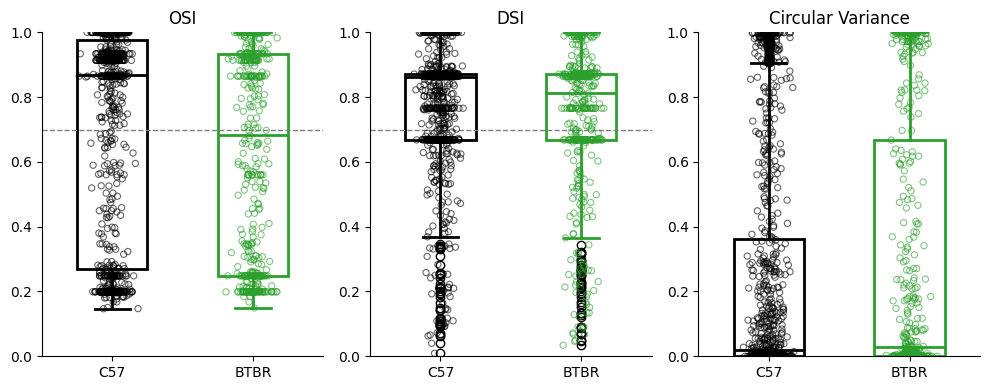

In [9]:
import matplotlib.pyplot as plt

genotypes = ['C57', 'BTBR']
metrics   = ['OSI', 'DSI', 'circ_var']
titles    = ['OSI', 'DSI', 'Circular Variance']
palette   = {'BTBR': '#2ca02c', 'C57': '#000000', 'Unknown': '#95a5a6'}

fig_mpl, axes = plt.subplots(1, 3, figsize=(10, 4))
rng_jitter = np.random.default_rng(0)

for ax, metric, title in zip(axes, metrics, titles):
    groups = [consolidated[consolidated['genotype'] == g][metric].values
              for g in genotypes]

    bp = ax.boxplot(
        groups, patch_artist=True, widths=0.5,
        boxprops=dict(facecolor='none', linewidth=2),
        whiskerprops=dict(linewidth=2),
        capprops=dict(linewidth=2),
        medianprops=dict(linewidth=2),
    )
    ax.set_xticks(range(1, len(genotypes) + 1))
    ax.set_xticklabels(genotypes)

    # Color each box / whisker / median by genotype
    for i, geno in enumerate(genotypes):
        color = palette.get(geno, '#95a5a6')
        bp['boxes'][i].set_edgecolor(color)
        bp['whiskers'][2*i].set_color(color)
        bp['whiskers'][2*i+1].set_color(color)
        bp['caps'][2*i].set_color(color)
        bp['caps'][2*i+1].set_color(color)
        bp['medians'][i].set_color(color)

    for i, grp in enumerate(groups):
        color = palette.get(genotypes[i], '#95a5a6')
        x_jitter = rng_jitter.normal(i + 1, 0.06, size=len(grp))
        ax.scatter(x_jitter, grp,
                   facecolors='none', edgecolors=color,
                   linewidths=0.8, s=20, alpha=0.6, zorder=3)

    if metric in ['OSI', 'DSI']:
        ax.axhline(OSI_THRESH, ls='--', color='gray', lw=1)
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig_mpl.savefig(OUTPUT_DIR / 'selectivity_by_genotype.svg',
                format='svg', bbox_inches='tight')
plt.show()

## 10. Does the difference hold when the animal is the unit?
> ✎ *To write: the test compares per-animal means (one number per animal), so the number of animals per genotype, not the number of neurons, sets its resolution. The printed count of distinct permutations is the smallest p the test can return.*

In [10]:
from math import comb

from itertools import combinations
from math import comb

def permutation_test(values_btbr, values_c57, n_perm=10000, rng_seed=42, max_exact=200_000):
    """
    Two-tailed permutation test on the difference of means (unit = animal).
    Exact enumeration of label assignments when there are <= max_exact of them,
    Monte Carlo otherwise. Float round-off is not allowed to decide the tail count.
    """
    a    = np.asarray(values_btbr, float)
    b    = np.asarray(values_c57, float)
    allv = np.concatenate([a, b])
    n, N = len(a), len(a) + len(b)
    observed = abs(a.mean() - b.mean())
    tol      = 1e-12 * max(1.0, observed)

    if comb(N, n) <= max_exact:
        idx  = np.array(list(combinations(range(N), n)))          # every way to pick the "BTBR" animals
        m_a  = allv[idx].mean(axis=1)
        m_b  = (allv.sum() - allv[idx].sum(axis=1)) / (N - n)
        return float(np.mean(np.abs(m_a - m_b) >= observed - tol))

    rng, count = np.random.default_rng(seed := rng_seed), 0
    for _ in range(n_perm):
        perm = rng.permutation(allv)
        if abs(perm[:n].mean() - perm[n:].mean()) >= observed - tol:
            count += 1
    return (count + 1) / (n_perm + 1)


def sem(x):
    x = np.asarray(x)
    return np.std(x, ddof=1) / np.sqrt(len(x))


print('=' * 55)
print('PERMUTATION TEST (unit = animal, n_perm=10000)')
print('=' * 55)

for col, lbl in [('OSI', 'OSI (GMM)'),
                 ('DSI', 'DSI (GMM)'),
                 ('circ_var', 'Circular variance')]:
    sub = consolidated.dropna(subset=[col])
    means_by_animal = sub.groupby(['animal_id', 'genotype'])[col].mean().reset_index()

    btbr_means = means_by_animal.loc[means_by_animal['genotype'] == 'BTBR', col].values
    c57_means  = means_by_animal.loc[means_by_animal['genotype'] == 'C57',  col].values
    if len(btbr_means) < 2 or len(c57_means) < 2:
        print(f'{lbl}: fewer than 2 animals in a group, skipped\n')
        continue

    p_perm = permutation_test(btbr_means, c57_means)
    n_distinct = comb(len(btbr_means) + len(c57_means), len(btbr_means))

    print(lbl + ':')
    print(f'  BTBR  mean={np.mean(btbr_means):.3f}  SEM={sem(btbr_means):.3f}  n={len(btbr_means)} animals')
    print(f'  C57   mean={np.mean(c57_means):.3f}  SEM={sem(c57_means):.3f}  n={len(c57_means)} animals')
    # Smallest attainable two-tailed p (no ties): equal group sizes give each split a
    # mirror image with the same |difference|, so it doubles.
    min_p = (2 if len(btbr_means) == len(c57_means) else 1) / n_distinct
    print(f'  Permutation p = {p_perm:.4f}   ({n_distinct} distinct label assignments, '
          f'min attainable p ≈ {min_p:.4f})')
    print()

PERMUTATION TEST (unit = animal, n_perm=10000)
OSI (GMM):
  BTBR  mean=0.625  SEM=0.019  n=4 animals
  C57   mean=0.706  SEM=0.017  n=7 animals
  Permutation p = 0.0152   (330 distinct label assignments, min attainable p ≈ 0.0030)

DSI (GMM):
  BTBR  mean=0.729  SEM=0.058  n=4 animals
  C57   mean=0.781  SEM=0.010  n=7 animals
  Permutation p = 0.2879   (330 distinct label assignments, min attainable p ≈ 0.0030)

Circular variance:
  BTBR  mean=0.356  SEM=0.169  n=4 animals
  C57   mean=0.239  SEM=0.012  n=7 animals
  Permutation p = 0.4576   (330 distinct label assignments, min attainable p ≈ 0.0030)



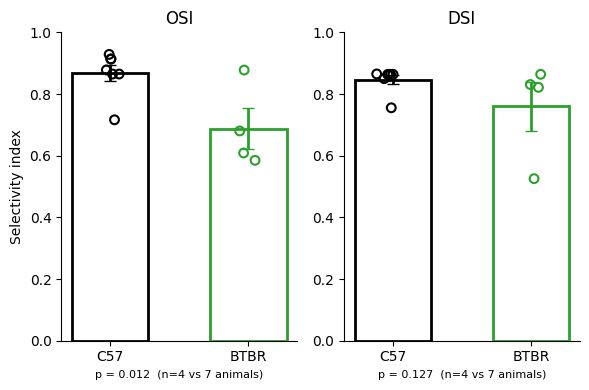

In [11]:
# ── OSI and DSI as bars (mean of per-animal means ± SEM; dots = animals) ──────
# Needs consolidated (section 8) and permutation_test / sem (section 10).
import matplotlib.pyplot as plt

GENO_ORDER = ['C57', 'BTBR']
palette    = {'BTBR': '#2ca02c', 'C57': '#000000'}

fig, axes = plt.subplots(1, 2, figsize=(6, 4))
rng_j = np.random.default_rng(0)

for ax, metric in zip(axes, ['OSI', 'DSI']):
    am = consolidated.groupby(['genotype', 'animal_id'])[metric].median().reset_index()   # one value per animal
    for i, g in enumerate(GENO_ORDER):
        vals = am.loc[am['genotype'] == g, metric].values
        err  = sem(vals) if len(vals) > 1 else 0
        ax.bar(i, vals.mean(), width=0.55, facecolor='none', edgecolor=palette[g], linewidth=2)
        ax.errorbar(i, vals.mean(), yerr=err, color=palette[g], capsize=4, lw=2)
        ax.scatter(i + rng_j.normal(0, 0.05, len(vals)), vals, s=40,
                   facecolors='none', edgecolors=palette[g], linewidths=1.5, zorder=3)

    b = am.loc[am['genotype'] == 'BTBR', metric].values
    c = am.loc[am['genotype'] == 'C57',  metric].values
    if len(b) >= 2 and len(c) >= 2:
        ax.set_xlabel(f'p = {permutation_test(b, c):.3f}  (n={len(b)} vs {len(c)} animals)', fontsize=8)

    ax.set_xticks(range(len(GENO_ORDER)))
    ax.set_xticklabels(GENO_ORDER)
    ax.set_ylim(0, 1)
    ax.set_title(metric)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Selectivity index')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'osi_dsi_bars.svg', format='svg', bbox_inches='tight')
plt.show()

In [12]:
# ── Why do the box plot and the bars show different C57 values? ───────────────
# Box plot line = median of pooled neurons.  Bars = mean of per-animal means.
rows = []
for metric in ['OSI', 'DSI']:
    for g in ['C57', 'BTBR']:
        sub    = consolidated[consolidated['genotype'] == g]
        per_an = sub.groupby('animal_id')[metric].agg(['mean', 'median', 'size'])
        rows.append({
            'metric': metric, 'genotype': g,
            'neurons: median':      sub[metric].median(),        # the line inside the box
            'neurons: mean':        sub[metric].mean(),          # pooled neurons
            'animals: mean of means':   per_an['mean'].mean(),   # the bar
            'animals: mean of medians': per_an['median'].mean(),
            'frac. neurons > 0.95': (sub[metric] > 0.95).mean(),
            'n neurons': len(sub), 'n animals': len(per_an),
        })
display(pd.DataFrame(rows).round(3).set_index(['metric', 'genotype']))

# Per animal: how many neurons each contributes and where their values sit
display(consolidated.groupby(['genotype', 'animal_id'])[['OSI', 'DSI']]
        .agg(['mean', 'median', 'size']).round(3).drop(columns=[('DSI', 'size')]))

neurons: median  neurons: mean  animals: mean of means  \
metric genotype                                                           
OSI    C57                 0.869          0.698                   0.706   
       BTBR                0.682          0.621                   0.625   
DSI    C57                 0.863          0.779                   0.781   
       BTBR                0.812          0.743                   0.729   

                 animals: mean of medians  frac. neurons > 0.95  n neurons  \
metric genotype                                                              
OSI    C57                          0.868                 0.263        839   
       BTBR                         0.688                 0.198        465   
DSI    C57                          0.846                 0.172        839   
       BTBR                         0.760                 0.157        465   

                 n animals  
metric genotype             
OSI    C57               7  
       BTBR              4  
DSI    C57               7  
       BTBR              4

OSI                DSI       
                                              mean median size   mean median
genotype animal_id                                                          
BTBR     BTBRL1030825_Reg_12_12_25           0.614  0.585   73  0.561  0.526
         BTBRR1_280825_Reg_15_12_25          0.594  0.609  121  0.780  0.822
         BTBR_R2_060725                      0.613  0.680  180  0.753  0.831
         BTBR_R2_270923_hembra_pasiva_Isaac  0.681  0.878   91  0.822  0.864
C57      C57L10300325_pasiva                 0.768  0.913   75  0.794  0.864
         C57L2_Isaac                         0.737  0.928   56  0.797  0.865
         C57R1230825_Reg_15_12_25            0.626  0.716  119  0.727  0.755
         C57R20010525_pasiva                 0.702  0.913  143  0.776  0.850
         C57R3230825_Reg_15_12_25            0.716  0.878  160  0.777  0.863
         C57_SM_Isaac                        0.711  0.865   63  0.804  0.864
         Delta 4-22 wt                       0.684  0.865  223  0.794  0.863

## 11. What is still open?
> ✎ *To write: separate confirmed from assumed. Starting list, derived from the code:*
>
> - **Open** — Is the GMM-based OSI/DSI invariant to preferred angle? The GMM is fitted on a linear 0–360° axis, so 0° and 315° are not neighbours to it. Compare `OSI`, `DSI` and `circ_var` across `pref_angle` bins.
> - **Open** — `MS_PER_FRAME` is the nominal 200 ms. Is the measured frame interval (`get_clean_frame_times`) the same, and does the difference shift the onset frame?
> - **Open** — `RESPONSIVE_STD = 3` and `OSI_THRESH = 0.7` have no citation yet.
> - **Assumed** — the response window (`RESP_START:RESP_END`) equals the stimulus duration and starts at onset, with no offset for indicator rise time.

In [13]:
# ── Continuous recordings + stimulus timing (one entry per animal) ────────────
# Needed by everything below. Paste after section 10.
GENO_ORDER = ['C57', 'BTBR']
palette    = {'BTBR': '#2ca02c', 'C57': '#000000'}

STIM_FRAMES   = RESP_END - RESP_START   # stimulus duration in frames (20 = 4 s)
F0_PERCENTILE = 10                      # baseline for the continuous ΔF/F (per neuron)

def load_traces(traces_csv: Path) -> np.ndarray:
    """Continuous fluorescence (T, N). Same parsing as extract_aligned_signals."""
    df = pd.read_csv(traces_csv, decimal=',', sep=None, engine='python')
    if df.columns[0].lower() in ['unnamed: 0', 'index', 'time', 'frame']:
        df.drop(df.columns[0], axis=1, inplace=True)
    return df.apply(pd.to_numeric, errors='coerce').fillna(0).values


session_data = {}
for animal in animals:
    aid = animal['animal_id']
    if aid not in animal_data:          # failed in section 7
        continue
    folder = animal['folder']

    ts_strs, millisec, sensores = parse_scope_txt(find_file(folder, SCOPE_KEYWORD))
    tstamp_stlog, estimulos     = parse_stim_txt(find_file(folder, STIM_KEYWORD))
    stimsnframes = align_stimuli_to_frames(
        ts_strs, millisec, sensores, tstamp_stlog, estimulos,
        ms_per_frame=MS_PER_FRAME)
    F = load_traces(find_file(folder, TRACES_KEYWORD))

    n_scope = len(get_clean_frame_times(millisec, sensores))
    if n_scope != F.shape[0]:
        print(f'  WARNING {aid}: {n_scope} scope frames vs {F.shape[0]} trace rows')

    onsets_by_angle = {int(stimsnframes[a, 0, 0]): stimsnframes[a, :, 1].astype(int)
                       for a in range(stimsnframes.shape[0])}
    n_bad = 0                                # frame 0 = onset not found by align_stimuli_to_frames
    for a in onsets_by_angle:
        ok = onsets_by_angle[a] > 0
        n_bad += int((~ok).sum())
        onsets_by_angle[a] = onsets_by_angle[a][ok]
    if n_bad:
        print(f'  WARNING {aid}: {n_bad} unaligned onsets (frame 0) dropped')
    F0 = np.percentile(F, F0_PERCENTILE, axis=0)

    session_data[aid] = {
        'genotype':        animal['genotype'],
        'F':               F,                              # (T, N) raw fluorescence
        'dff':             (F - F0) / (F0 + 1e-10),        # (T, N) continuous ΔF/F
        'onsets_by_angle': onsets_by_angle,
        'all_onsets':      np.sort(np.concatenate(list(onsets_by_angle.values()))),
        'responsive':      animal_data[aid]['responsive'],
    }
    s = session_data[aid]
    print(f"{aid:16s} [{s['genotype']:4}]  {F.shape[0]} frames "
          f"({F.shape[0] / SAMPLING_RATE / 60:.1f} min)  {F.shape[1]} neurons  "
          f"{len(s['all_onsets'])} stimuli")

  WARNING BTBR_R2_060725: 6071 scope frames vs 6103 trace rows
  WARNING BTBR_R2_060725: 640 unaligned onsets (frame 0) dropped
BTBR_R2_060725   [BTBR]  6103 frames (20.3 min)  187 neurons  80 stimuli
  WARNING BTBR_R2_270923_hembra_pasiva_Isaac: 4370 scope frames vs 4449 trace rows
  WARNING BTBR_R2_270923_hembra_pasiva_Isaac: 512 unaligned onsets (frame 0) dropped
BTBR_R2_270923_hembra_pasiva_Isaac [BTBR]  4449 frames (14.8 min)  93 neurons  64 stimuli
  WARNING BTBRL1030825_Reg_12_12_25: 3019 scope frames vs 3021 trace rows
  WARNING BTBRL1030825_Reg_12_12_25: 640 unaligned onsets (frame 0) dropped
BTBRL1030825_Reg_12_12_25 [BTBR]  3021 frames (10.1 min)  92 neurons  80 stimuli
  WARNING BTBRR1_280825_Reg_15_12_25: 5462 scope frames vs 5500 trace rows
  WARNING BTBRR1_280825_Reg_15_12_25: 640 unaligned onsets (frame 0) dropped
BTBRR1_280825_Reg_15_12_25 [BTBR]  5500 frames (18.3 min)  127 neurons  80 stimuli
  WARNING C57_SM_Isaac: 4319 scope frames vs 4350 trace rows
  WARNING C57_

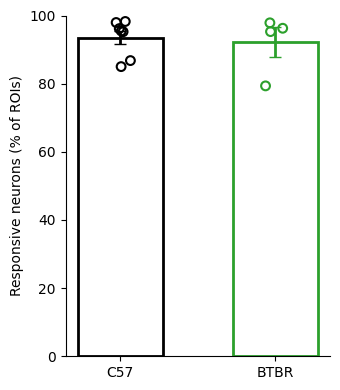

BTBR 92.2 ± 4.3 %  (n=4 animals)   C57 93.5 ± 2.0 %  (n=7 animals)   permutation p = 0.733


,n_responsive,n_total
genotype,,
BTBR,465,499
C57,839,912


In [14]:
# ── Proportion of responsive neurons per genotype ─────────────────────────────
# Needs summary_df (section 8) and permutation_test / sem (section 10).
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3.5, 4))
rng_j = np.random.default_rng(0)

for i, g in enumerate(GENO_ORDER):
    vals = summary_df.loc[summary_df['genotype'] == g, 'pct_responsive'].values
    err  = sem(vals) if len(vals) > 1 else 0
    ax.bar(i, vals.mean(), width=0.55, facecolor='none',
           edgecolor=palette[g], linewidth=2)
    ax.errorbar(i, vals.mean(), yerr=err, color=palette[g], capsize=4, lw=2)
    ax.scatter(i + rng_j.normal(0, 0.05, len(vals)), vals, s=40,
               facecolors='none', edgecolors=palette[g], linewidths=1.5, zorder=3)

ax.set_xticks(range(len(GENO_ORDER)))
ax.set_xticklabels(GENO_ORDER)
ax.set_ylabel('Responsive neurons (% of ROIs)')
ax.set_ylim(0, 100)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'pct_responsive_by_genotype.svg', format='svg', bbox_inches='tight')
plt.show()

# Each dot = one animal. Test: permutation on per-animal percentages.
b = summary_df.loc[summary_df['genotype'] == 'BTBR', 'pct_responsive'].values
c = summary_df.loc[summary_df['genotype'] == 'C57',  'pct_responsive'].values
print(f'BTBR {b.mean():.1f} ± {sem(b):.1f} %  (n={len(b)} animals)   '
      f'C57 {c.mean():.1f} ± {sem(c):.1f} %  (n={len(c)} animals)   '
      f'permutation p = {permutation_test(b, c):.3f}')
display(summary_df.groupby('genotype')[['n_responsive', 'n_total']].sum())

In [15]:
# ── Calcium events per minute: whole recording / stimulation / gray screen ────
BINARIZE_THR       = 0.5      # SDs above the neuron's mean (same criterion as the spontaneous analysis)
THRESH_FROM        = 'all'    # mean/SD from 'all' frames of the recording, or from 'gray' frames only
GRAY_MARGIN_FR     = 0        # frames after each stimulus offset left out of "gray" (indicator decay)
GRAY_INCLUDE_EDGES = False    # False: gray = intervals between the first onset and the last offset

def binarize_traces(traces, threshold_std=BINARIZE_THR, ref_mask=None):
    """Active = 1 where trace > mean + threshold_std * SD, per neuron. (T, N) -> (T, N).
    ref_mask: frames used to compute mean/SD (None = all frames)."""
    ref  = traces if ref_mask is None else traces[ref_mask]
    mean = ref.mean(axis=0)
    std  = ref.std(axis=0)
    std[std == 0] = 1
    return (traces > mean + threshold_std * std).astype(float)


def window_masks(T, onsets):
    """Boolean frame masks for the three analysis windows."""
    stim = np.zeros(T, bool)
    post = np.zeros(T, bool)
    for o in onsets:
        stim[o:o + STIM_FRAMES] = True
        post[o + STIM_FRAMES:o + STIM_FRAMES + GRAY_MARGIN_FR] = True
    if GRAY_INCLUDE_EDGES:
        in_span = np.ones(T, bool)
    else:
        in_span = np.zeros(T, bool)
        in_span[onsets.min():onsets.max() + STIM_FRAMES] = True
    return {'total': np.ones(T, bool), 'stim': stim, 'gray': in_span & ~stim & ~post}


def events_per_min(binary, mask):
    """0→1 transitions whose onset frame falls inside `mask`, per minute of masked time."""
    onsets  = np.diff(binary, axis=0) > 0          # onsets[t-1] = transition into frame t
    n_ev    = onsets[mask[1:]].sum(axis=0)
    minutes = mask.sum() / SAMPLING_RATE / 60
    return n_ev / minutes


rows = []
for aid, s in session_data.items():
    T, N   = s['F'].shape
    masks  = window_masks(T, s['all_onsets'])
    ref    = masks['gray'] if THRESH_FROM == 'gray' else None
    binary = binarize_traces(s['F'], BINARIZE_THR, ref_mask=ref)

    resp = np.zeros(N, bool)
    resp[s['responsive']] = True
    out = pd.DataFrame({'animal_id': aid, 'genotype': s['genotype'],
                        'neuron': np.arange(N), 'responsive': resp})
    for name, m in masks.items():
        out[f'ev_min_{name}'] = events_per_min(binary, m)
    rows.append(out)

    mins = {k: m.sum() / SAMPLING_RATE / 60 for k, m in masks.items()}
    print(f"{aid:16s} minutes → total {mins['total']:.1f} | "
          f"stim {mins['stim']:.1f} | gray {mins['gray']:.1f}")

rates_df = pd.concat(rows, ignore_index=True)
rates_df.to_csv(OUTPUT_DIR / 'event_rates_by_window.csv', index=False)
display(rates_df.groupby('genotype')[['ev_min_total', 'ev_min_stim', 'ev_min_gray']].median().round(2))

BTBR_R2_060725   minutes → total 20.3 | stim 5.3 | gray 12.1
BTBR_R2_270923_hembra_pasiva_Isaac minutes → total 14.8 | stim 4.3 | gray 9.7
BTBRL1030825_Reg_12_12_25 minutes → total 10.1 | stim 3.0 | gray 6.9
BTBRR1_280825_Reg_15_12_25 minutes → total 18.3 | stim 5.3 | gray 12.1
C57_SM_Isaac     minutes → total 14.5 | stim 4.3 | gray 9.7
C57L10300325_pasiva minutes → total 15.2 | stim 4.3 | gray 9.6
C57L2_Isaac      minutes → total 14.5 | stim 4.2 | gray 9.7
C57R1230825_Reg_15_12_25 minutes → total 18.2 | stim 5.2 | gray 12.2
C57R20010525_pasiva minutes → total 17.5 | stim 4.3 | gray 9.6
C57R3230825_Reg_15_12_25 minutes → total 18.0 | stim 5.3 | gray 12.2
Delta 4-22 wt    minutes → total 14.4 | stim 4.2 | gray 9.7


,ev_min_total,ev_min_stim,ev_min_gray
genotype,,,
BTBR,3.91,4.69,2.97
C57,3.06,3.75,2.80


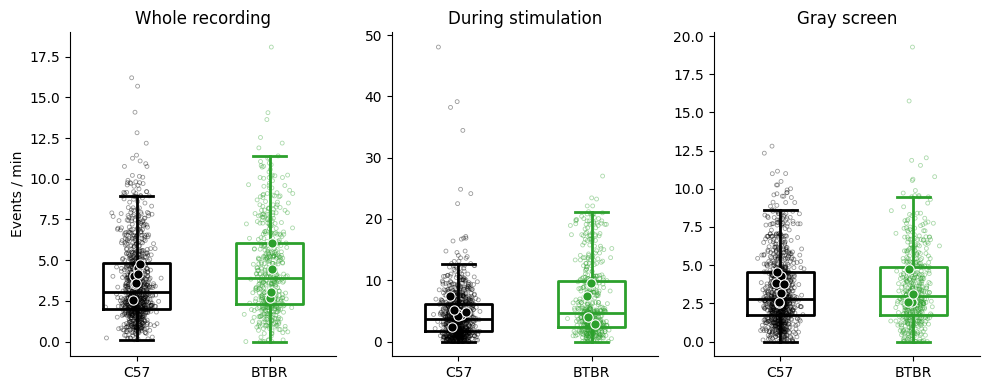

Permutation tests on per-animal means
  Whole recording      BTBR 4.05 ± 0.78 | C57 3.87 ± 0.28 events/min | p = 0.809  (n=4 vs 7 animals)
  During stimulation   BTBR 5.96 ± 1.57 | C57 4.72 ± 0.57 events/min | p = 0.400  (n=4 vs 7 animals)
  Gray screen          BTBR 3.26 ± 0.51 | C57 3.54 ± 0.30 events/min | p = 0.597  (n=4 vs 7 animals)


In [16]:
# ── Events per minute by genotype and window ──────────────────────────────────
# Small dots = neurons (all ROIs, responsive or not). Filled dots = animal means.
import matplotlib.pyplot as plt

windows = [('total', 'Whole recording'),
           ('stim',  'During stimulation'),
           ('gray',  'Gray screen')]

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
rng_j = np.random.default_rng(0)

for ax, (w, title) in zip(axes, windows):
    col = f'ev_min_{w}'
    for i, g in enumerate(GENO_ORDER):
        sub  = rates_df[rates_df['genotype'] == g]
        vals = sub[col].values
        ax.boxplot([vals], positions=[i], widths=0.5, showfliers=False,
                   boxprops=dict(color=palette[g], linewidth=2),
                   whiskerprops=dict(color=palette[g], linewidth=2),
                   capprops=dict(color=palette[g], linewidth=2),
                   medianprops=dict(color=palette[g], linewidth=2))
        ax.scatter(i + rng_j.normal(0, 0.06, len(vals)), vals, s=8,
                   facecolors='none', edgecolors=palette[g],
                   linewidths=0.6, alpha=0.4, zorder=2)
        am = sub.groupby('animal_id')[col].mean()
        ax.scatter(i + rng_j.normal(0, 0.03, len(am)), am.values, s=45,
                   color=palette[g], edgecolors='white', linewidths=0.8, zorder=4)
    ax.set_xticks(range(len(GENO_ORDER)))
    ax.set_xticklabels(GENO_ORDER)
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('Events / min')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'event_rates_by_window.svg', format='svg', bbox_inches='tight')
plt.show()

# Unit of inference = animal (mean over neurons, then permutation across animals)
print('Permutation tests on per-animal means')
for w, title in windows:
    col = f'ev_min_{w}'
    am  = rates_df.groupby(['genotype', 'animal_id'])[col].mean().reset_index()
    b   = am.loc[am['genotype'] == 'BTBR', col].values
    c   = am.loc[am['genotype'] == 'C57',  col].values
    if len(b) < 2 or len(c) < 2:
        print(f'  {title}: fewer than 2 animals in a group, skipped')
        continue
    print(f'  {title:20s} BTBR {b.mean():.2f} ± {sem(b):.2f} | '
          f'C57 {c.mean():.2f} ± {sem(c):.2f} events/min | '
          f'p = {permutation_test(b, c):.3f}  (n={len(b)} vs {len(c)} animals)')

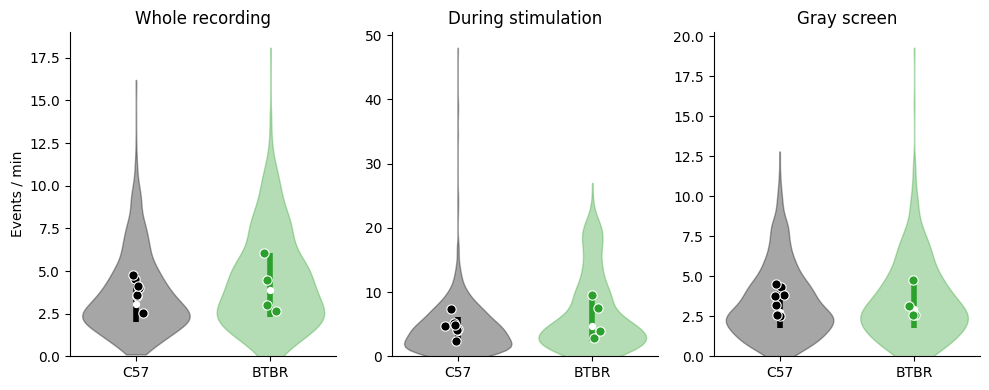

Permutation tests on per-animal means
  Whole recording      BTBR 4.05 ± 0.78 | C57 3.87 ± 0.28 events/min | p = 0.809  (n=4 vs 7 animals)
  During stimulation   BTBR 5.96 ± 1.57 | C57 4.72 ± 0.57 events/min | p = 0.400  (n=4 vs 7 animals)
  Gray screen          BTBR 3.26 ± 0.51 | C57 3.54 ± 0.30 events/min | p = 0.597  (n=4 vs 7 animals)


In [17]:
# ── Events per minute by genotype and window (violin) ─────────────────────────
# Violin = distribution over neurons (all ROIs). Filled dots = animal means.
import matplotlib.pyplot as plt

windows = [('total', 'Whole recording'),
           ('stim',  'During stimulation'),
           ('gray',  'Gray screen')]

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
rng_j = np.random.default_rng(0)

for ax, (w, title) in zip(axes, windows):
    col = f'ev_min_{w}'
    for i, g in enumerate(GENO_ORDER):
        sub  = rates_df[rates_df['genotype'] == g]
        vals = sub[col].values

        parts = ax.violinplot([vals], positions=[i], widths=0.8,
                              showmedians=False, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(palette[g]); pc.set_edgecolor(palette[g])
            pc.set_alpha(0.35)

        q1, med, q3 = np.percentile(vals, [25, 50, 75])       # median + IQR
        ax.vlines(i, q1, q3, color=palette[g], lw=4, zorder=3)
        ax.scatter(i, med, s=18, color='white', zorder=4)

        am = sub.groupby('animal_id')[col].mean()
        ax.scatter(i + rng_j.normal(0, 0.04, len(am)), am.values, s=45,
                   color=palette[g], edgecolors='white', linewidths=0.8, zorder=5)

    ax.set_xticks(range(len(GENO_ORDER)))
    ax.set_xticklabels(GENO_ORDER)
    ax.set_ylim(bottom=0)
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_ylabel('Events / min')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'event_rates_by_window_violin.svg', format='svg', bbox_inches='tight')
plt.show()

# Unit of inference = animal (mean over neurons, then permutation across animals)
print('Permutation tests on per-animal means')
for w, title in windows:
    col = f'ev_min_{w}'
    am  = rates_df.groupby(['genotype', 'animal_id'])[col].mean().reset_index()
    b   = am.loc[am['genotype'] == 'BTBR', col].values
    c   = am.loc[am['genotype'] == 'C57',  col].values
    if len(b) < 2 or len(c) < 2:
        print(f'  {title}: fewer than 2 animals in a group, skipped')
        continue
    print(f'  {title:20s} BTBR {b.mean():.2f} ± {sem(b):.2f} | '
          f'C57 {c.mean():.2f} ± {sem(c):.2f} events/min | '
          f'p = {permutation_test(b, c):.3f}  (n={len(b)} vs {len(c)} animals)')

ev_min_total  ev_min_stim  ev_min_gray
threshold from genotype                                        
all            BTBR              3.91         4.69         2.97
               C57               3.06         3.75         2.80
gray           BTBR              3.91         4.69         3.13
               C57               3.03         3.57         2.79

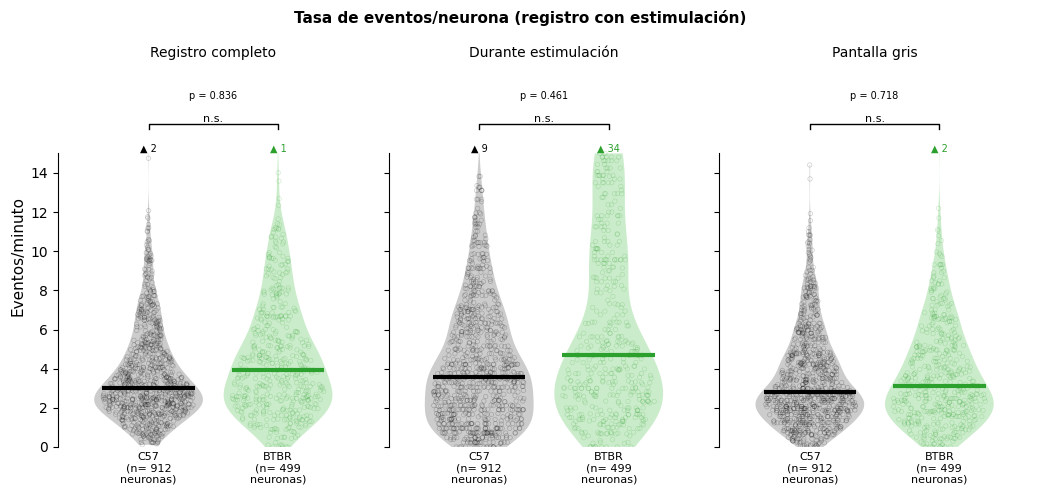

In [18]:
# ── Events/min violin in the style of the spontaneous-events figure ───────────
# Needs cell 1 (session_data), cell 3 (window_masks, binarize_traces, events_per_min)
# and permutation_test (section 10).
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

FIG_THRESH_FROM = 'gray'   # binarization reference: 'gray' = mean/SD of gray frames (closest to the spontaneous
                           # analysis, which uses a stimulation-free recording); 'all' = whole recording
JITTER_FRAC = 0.85          # dots spread over this fraction of the violin's local width (0 = a single column)
YMAX = 15                  # y-axis is cut here (data above it are not drawn; medians and tests use ALL data). None = automatic
WINDOWS = [('total', 'Registro completo'),
           ('stim',  'Durante estimulación'),
           ('gray',  'Pantalla gris')]
STYLE = {'C57':  dict(fill='0.5',     line='k',       dot='k'),
         'BTBR': dict(fill='#7fd17f', line='#2ca02c', dot='#2ca02c')}


def rates_for(thresh_from):
    """Events/min per neuron and window (all ROIs). Same computation as cell 3, threshold reference selectable."""
    rows = []
    for aid, s in session_data.items():
        T, N   = s['F'].shape
        masks  = window_masks(T, s['all_onsets'])
        ref    = masks['gray'] if thresh_from == 'gray' else None
        binary = binarize_traces(s['F'], BINARIZE_THR, ref_mask=ref)
        out = pd.DataFrame({'animal_id': aid, 'genotype': s['genotype'], 'neuron': np.arange(N)})
        for name, m in masks.items():
            out[f'ev_min_{name}'] = events_per_min(binary, m)
        rows.append(out)
    return pd.concat(rows, ignore_index=True)


# How much does the binarization reference change the rates? (median events/min per neuron)
cmp = {t: rates_for(t).groupby('genotype')[['ev_min_total', 'ev_min_stim', 'ev_min_gray']].median()
       for t in ('all', 'gray')}
display(pd.concat(cmp, names=['threshold from']).round(2))

fig_rates = rates_for(FIG_THRESH_FROM)
fig_rates.to_csv(OUTPUT_DIR / f'event_rates_fig1_thr-{FIG_THRESH_FROM}.csv', index=False)


def swarm_violin(ax, x, vals, sty, rng, half_width=0.42, ymax=None):
    """Filled violin (density) + dots spread inside it + thick median line.
    Density and median use all values; only the part <= ymax is drawn."""
    hi    = vals.max() if ymax is None else min(vals.max(), ymax)
    shown = vals[vals <= hi]
    if len(vals) > 2 and np.ptp(vals) > 0 and vals.min() < hi:
        ys   = np.linspace(vals.min(), hi, 200)
        dens = gaussian_kde(vals)(ys)
        dens = dens / dens.max() * half_width
        ax.fill_betweenx(ys, x - dens, x + dens, facecolor=sty['fill'], alpha=0.4, edgecolor='none', zorder=1)
        spread = np.interp(shown, ys, dens)
    else:
        spread = np.full(len(shown), 0.05)
    ax.scatter(x + rng.uniform(-1, 1, len(shown)) * spread * JITTER_FRAC, shown, s=10,
               facecolors='none', edgecolors=sty['dot'], linewidths=0.5, alpha=0.20, zorder=2)
    med = np.median(vals)
    if ymax is None or med <= ymax:
        ax.hlines(med, x - 0.85 * half_width, x + 0.85 * half_width, color=sty['line'], lw=3, zorder=4)
    else:
        ax.text(x, ymax, f'mediana {med:.1f}', ha='center', va='top', fontsize=7, color=sty['line'])
    n_cut = len(vals) - len(shown)
    if n_cut:                                                          # neurons above the cut
        ax.text(x, hi, f'▲ {n_cut}', ha='center', va='bottom', fontsize=7, color=sty['line'])


def stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'


top = YMAX or max(fig_rates[f'ev_min_{w}'].max() for w, _ in WINDOWS) * 1.05
fig, axes = plt.subplots(1, 3, figsize=(10.5, 5), sharey=True)
rng = np.random.default_rng(0)

for ax, (w, title) in zip(axes, WINDOWS):
    col = f'ev_min_{w}'
    for i, g in enumerate(['C57', 'BTBR']):
        swarm_violin(ax, i, fig_rates.loc[fig_rates['genotype'] == g, col].values, STYLE[g], rng, ymax=YMAX)

    # Significance: permutation test on per-animal means (unit = animal)
    am = fig_rates.groupby(['genotype', 'animal_id'])[col].mean().reset_index()
    b, c = (am.loc[am['genotype'] == g_, col].values for g_ in ('BTBR', 'C57'))
    if len(b) >= 2 and len(c) >= 2:
        p = permutation_test(b, c)
        y = top * 1.10
        ax.plot([0, 0, 1, 1], [y * 0.985, y, y, y * 0.985], color='k', lw=1)
        ax.text(0.5, y, f'{stars(p)}', ha='center', va='bottom', fontsize=11 if p < 0.05 else 8)
        ax.text(0.5, y * 1.07, f'p = {p:.3f}', ha='center', va='bottom', fontsize=7)

    n_by_g = fig_rates['genotype'].value_counts()
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'{g}\n(n= {n_by_g[g]}\nneuronas)' for g in ('C57', 'BTBR')], fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(-0.7, 1.7)
    ax.set_ylim(0, top * 1.3)
    if YMAX:
        ax.set_yticks(np.arange(0, YMAX + 1, 2))
        ax.spines['left'].set_bounds(0, YMAX)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.tick_params(axis='x', length=0)
axes[0].set_ylabel('Eventos/minuto', fontsize=11)
fig.suptitle('Tasa de eventos/neurona (registro con estimulación)', fontweight='bold', fontsize=11)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig1_event_rates_violin.svg', format='svg', bbox_inches='tight')
plt.show()

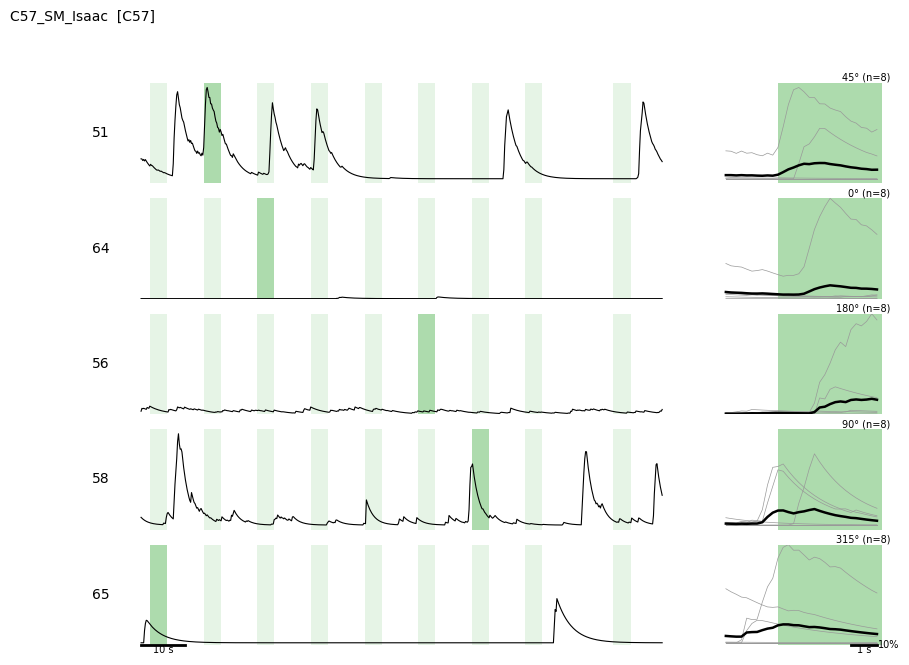

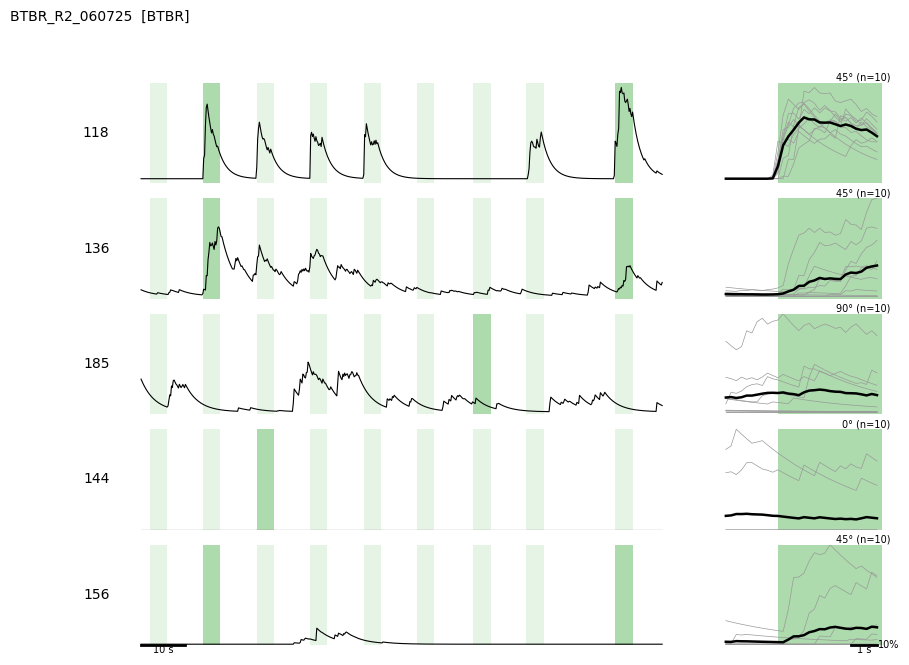

In [19]:
# ── Example calcium traces aligned to the stimulus ────────────────────────────
# Left: continuous ΔF/F excerpt; green = every stimulus, darker green = the angle shown on the right.
# Right: that angle's trials aligned to onset (gray = single trials, black = mean).
from matplotlib.gridspec import GridSpec

N_EXAMPLES    = 5
PICK          = 'top'    # 'top' = largest evoked ΔF/F at the best angle, 'random' = random responsive neurons
ANGLE         = None     # None = each neuron's best angle; or an angle from the stimulus set, e.g. 90
EXCERPT_LEN_S = 120      # length of the continuous excerpt on the left (s)
GREEN         = '#5cb85c'

def evoked_by_angle(dff, onsets_by_angle):
    """Mean ΔF/F over the stimulus window, per angle: ((n_angles, N), sorted angles)."""
    angs, out = sorted(onsets_by_angle), []
    for a in angs:
        w = [dff[o:o + STIM_FRAMES].mean(axis=0)
             for o in onsets_by_angle[a] if o + STIM_FRAMES <= len(dff)]
        out.append(np.mean(w, axis=0))
    return np.array(out), angs


def pick_neurons(s, n, how='top', seed=0):
    pool = np.array(s['responsive'])
    if how == 'random':
        return np.random.default_rng(seed).choice(pool, min(n, len(pool)), replace=False)
    ev, _ = evoked_by_angle(s['dff'], s['onsets_by_angle'])
    return pool[np.argsort(ev.max(axis=0)[pool])[::-1][:n]]


def plot_aligned_examples(aid, neuron_ids=None, angle=ANGLE):
    s   = session_data[aid]
    dff = s['dff']
    T   = len(dff)
    if neuron_ids is None:
        neuron_ids = pick_neurons(s, N_EXAMPLES, PICK)
    ev, angs = evoked_by_angle(dff, s['onsets_by_angle'])

    t_ax  = np.arange(-FRAMES_BEFORE, FRAMES_AFTER) / SAMPLING_RATE
    start = max(0, s['all_onsets'].min() - FRAMES_BEFORE)
    stop  = min(T, start + int(EXCERPT_LEN_S * SAMPLING_RATE))
    t_ex  = np.arange(start, stop) / SAMPLING_RATE

    fig = plt.figure(figsize=(10, 1.3 * len(neuron_ids) + 0.8))
    gs  = GridSpec(len(neuron_ids), 2, width_ratios=[4, 1.2], wspace=0.08, hspace=0.15)

    for r, n in enumerate(neuron_ids):
        a_best = angs[int(np.argmax(ev[:, n]))] if angle is None else angle
        ax_l, ax_r = fig.add_subplot(gs[r, 0]), fig.add_subplot(gs[r, 1])

        for a, oo in s['onsets_by_angle'].items():           # left panel
            for o in oo:
                if start <= o < stop:
                    ax_l.axvspan(o / SAMPLING_RATE, (o + STIM_FRAMES) / SAMPLING_RATE,
                                 color=GREEN, alpha=0.5 if a == a_best else 0.15, lw=0)
        ax_l.plot(t_ex, dff[start:stop, n], color='k', lw=0.8)

        trials = np.array([dff[o - FRAMES_BEFORE:o + FRAMES_AFTER, n]        # right panel
                           for o in s['onsets_by_angle'][a_best]
                           if o - FRAMES_BEFORE >= 0 and o + FRAMES_AFTER <= T])
        ax_r.axvspan(0, STIM_FRAMES / SAMPLING_RATE, color=GREEN, alpha=0.5, lw=0)
        ax_r.plot(t_ax, trials.T, color='0.6', lw=0.5)
        ax_r.plot(t_ax, trials.mean(axis=0), color='k', lw=1.8)
        lo = min(ax_l.get_ylim()[0], trials.min())           # same vertical scale in both panels
        hi = max(ax_l.get_ylim()[1], trials.max())
        ax_l.set_ylim(lo, hi); ax_r.set_ylim(lo, hi)
        ax_r.text(1, 1, f'{a_best}° (n={len(trials)})', transform=ax_r.transAxes,
                  ha='right', va='bottom', fontsize=7)

        ax_l.set_ylabel(f'{n}', rotation=0, ha='right', va='center')
        for ax in (ax_l, ax_r):
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_visible(False)

    # Scale bars (last row): 10 % ΔF/F, 1 s on the right; 10 s on the left
    ylo = ax_r.get_ylim()[0]
    x1  = t_ax[-1]
    ax_r.plot([x1 - 1, x1], [ylo, ylo], 'k', lw=2, clip_on=False)
    ax_r.plot([x1, x1], [ylo, ylo + 0.1], 'k', lw=2, clip_on=False)
    ax_r.text(x1 - 0.5, ylo, '1 s', ha='center', va='top', fontsize=7)
    ax_r.text(x1 + 0.05, ylo + 0.05, '10%', ha='left', va='center', fontsize=7)
    ax_l.plot([t_ex[0], t_ex[0] + 10], [ylo, ylo], 'k', lw=2, clip_on=False)
    ax_l.text(t_ex[0] + 5, ylo, '10 s', ha='center', va='top', fontsize=7)

    fig.suptitle(f"{aid}  [{s['genotype']}]", fontsize=10, x=0.02, ha='left')
    fig.savefig(OUTPUT_DIR / f'{aid}_aligned_traces.svg', format='svg', bbox_inches='tight')
    plt.show()


for g in GENO_ORDER:                     # one example animal per genotype
    plot_aligned_examples(next(a for a, d in session_data.items() if d['genotype'] == g))

  C57_SM_Isaac: block = stimuli 0-7, angles [315, 45, 0, 135, 270, 180, 90, 225]


,neuron,tag,tier,osi_vec,osi_gmm,pref_ori,peak_dff,snr,reliab,hits_in_block,z_gray_block
0,51,tuned 0°,2,0.26,0.20,7.30,5.736877e+12,3626442.23,0.25,3,32514827.31
1,56,tuned 0°,2,0.45,0.91,179.53,2.190168e+12,87.85,0.38,1,47.40
2,30,tuned 0°,2,0.47,0.93,174.10,7.079655e+08,47.67,0.38,3,1584.13
3,2,tuned 90°,1,0.48,0.91,80.83,8.465426e+11,10.33,0.50,3,119.86
4,45,tuned 90°,1,0.77,0.92,101.02,1.307103e+08,5.28,0.50,2,161.71
5,58,tuned 90°,2,0.55,1.00,99.34,1.600088e+12,27.53,0.38,2,330.72
6,61,"responsive, untuned",0,0.04,0.72,171.55,4.392700e+02,99.04,1.00,8,206.38
7,63,"responsive, untuned",0,0.26,0.84,176.77,6.219838e+11,12.61,0.50,8,48.32
8,47,non-responsive (spontaneous),1,1.00,NaN,90.00,5.000000e-02,53201.35,0.25,0,65038288.62
9,50,non-responsive (spontaneous),1,0.38,NaN,109.25,2.174257e+11,96.36,0.38,0,610.13


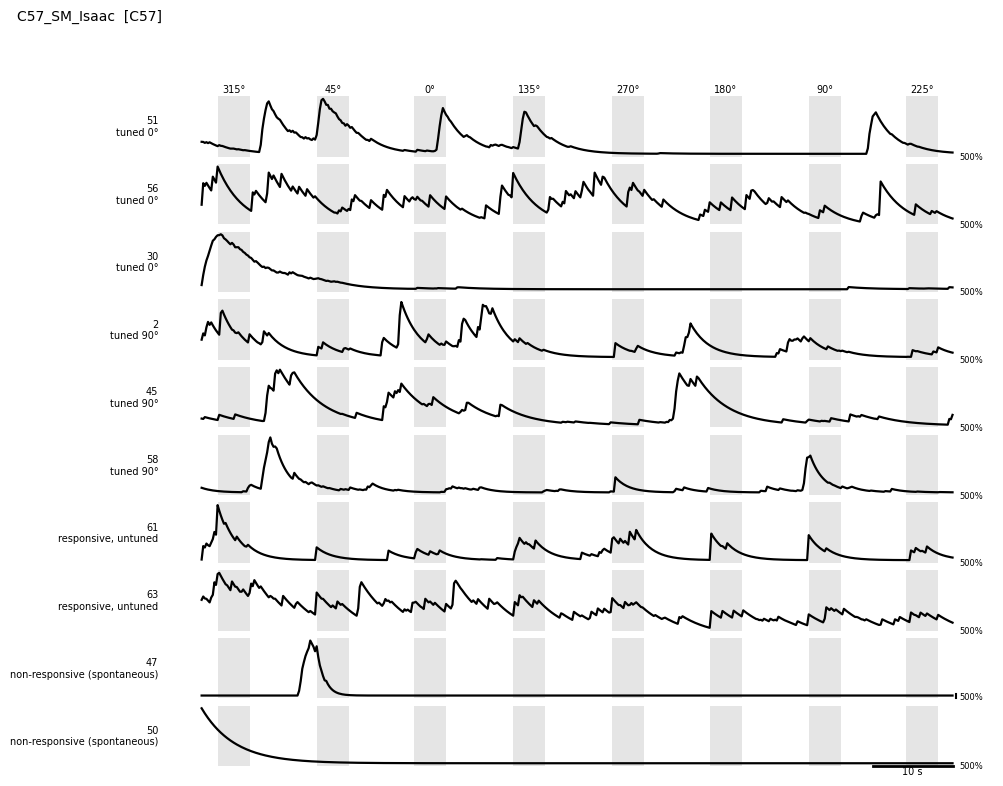

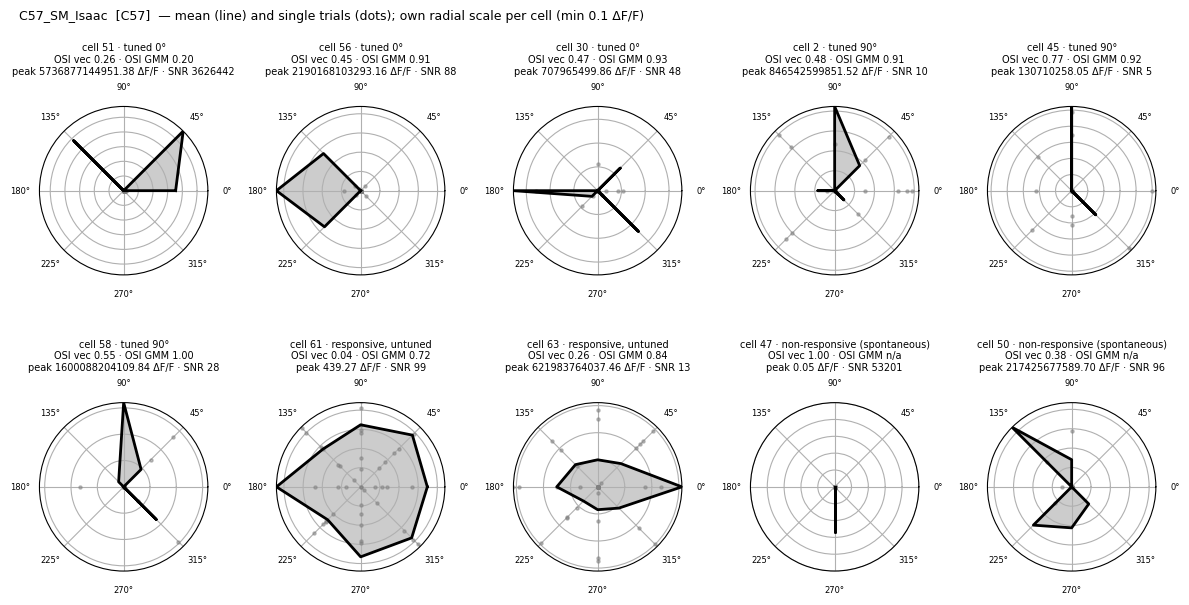

  BTBR_R2_060725: block = stimuli 0-7, angles [270, 45, 0, 225, 180, 315, 90, 135]


,neuron,tag,tier,osi_vec,osi_gmm,pref_ori,peak_dff,snr,reliab,hits_in_block,z_gray_block
0,92,tuned 0°,0,0.63,0.99,8.99,5.956227e+09,128.04,0.8,5,420.15
1,170,tuned 0°,0,0.77,0.44,171.96,5.328873e+11,53.53,0.6,3,131.97
2,183,tuned 0°,0,0.63,1.00,22.05,1.262261e+09,26.93,0.8,5,59.75
3,141,tuned 90°,1,0.49,0.93,81.43,1.200360e+12,86.29,1.0,1,199.20
4,137,tuned 90°,1,0.43,0.91,97.84,7.683458e+11,54.56,0.7,7,414.72
5,176,tuned 90°,1,0.78,0.44,90.00,3.462289e+05,1.39,0.4,2,65.12
6,96,"responsive, untuned",0,0.18,0.98,52.54,4.874954e+11,1007.94,0.5,4,9684.92
7,4,"responsive, untuned",0,0.11,0.20,110.16,2.188959e+09,210.27,0.8,3,286.66
8,166,non-responsive (spontaneous),0,0.71,NaN,156.79,2.300000e+00,1.71,0.3,0,38.86
9,46,non-responsive (spontaneous),0,0.33,NaN,180.00,4.366000e+01,0.53,0.1,0,8.15


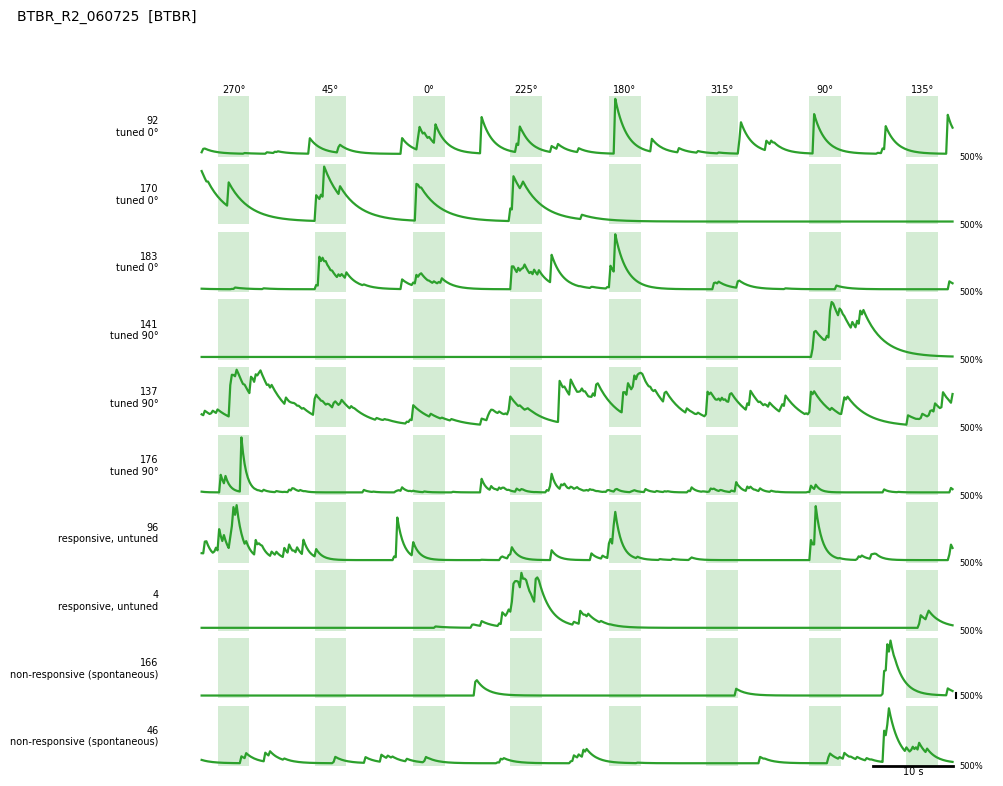

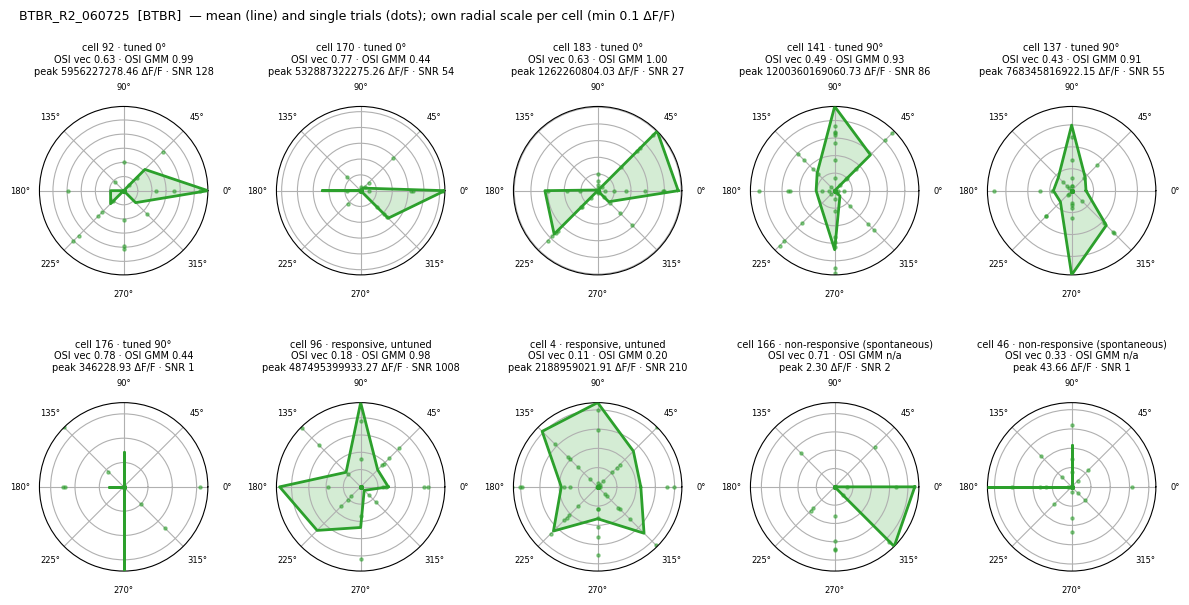

In [20]:
# ── 10 example neurons that clearly fire: raw traces over one block + polar tuning ──
# Needs session_data (cell 1) and animal_data (section 7).
import matplotlib.pyplot as plt

# Composition of the 10 cells
N_TUNED_A, N_TUNED_B, N_UNTUNED, N_NONRESP = 3, 3, 2, 2
ORI_A, ORI_B    = 0, 90     # orientations (deg, mod 180); must exist in the stimulus set
ORI_TOL         = 22.5      # preferred orientation within this of A / B counts as tuned to it (deg)

# "Fires" = evoked ΔF/F above MIN_SNR × the neuron's baseline noise (MAD of pre-stimulus frames)
MIN_SNR         = 5
TUNED_MIN_OSI   = 0.6       # strict tier for tuned cells (relaxed automatically if not enough are found)
MIN_RELIABILITY = 0.6       # strict tier: fraction of trials at the best angle with response > 3 × noise
UNTUNED_MAX_OSI = 0.3       # strict tier for "responsive, untuned"
DECAY_FR        = 10        # frames after stimulus offset not counted as gray (indicator decay)

# Block = consecutive stimuli, in presentation order
BLOCK_START = None          # None = the window with the most distinct angles; or an index
BLOCK_SIZE  = None          # None = one stimulus per angle (8); len(all_onsets) = whole session
PAD_S       = 2             # seconds shown before/after the block
SHARED_SCALE = False        # False: each row scaled to its own amplitude (with its own scale bar)
EXAMPLE_ANIMAL = {'C57': None, 'BTBR': None}    # None = first animal of the genotype

R_MIN = 0.1                 # smallest radial range in the polar plots (ΔF/F)
TRACE_LW = 1.6              # line width of the raw traces
SHOW_ANGLE_LABELS = True    # angle text above the first row (turn off if you add the gratings there)
GENO_STYLE = {              # trace / shading colours per genotype
    'C57':  {'trace': 'k',       'shade': '0.5',     'alpha': 0.20},
    'BTBR': {'trace': '#2ca02c', 'shade': '#2ca02c', 'alpha': 0.20},
}


def ori_dist(a, b):
    """Circular distance between orientations (deg, period 180)."""
    return np.abs((a - b + 90) % 180 - 90)


def trial_responses(dff, onsets_by_angle):
    """{angle: (n_trials, N)}: mean ΔF/F in the stimulus window minus the pre-stimulus mean."""
    out = {}
    for a, oo in onsets_by_angle.items():
        out[a] = np.array([dff[o:o + STIM_FRAMES].mean(axis=0) - dff[o - FRAMES_BEFORE:o].mean(axis=0)
                           for o in oo if o - FRAMES_BEFORE >= 0 and o + STIM_FRAMES <= len(dff)])
    return out


def orientation_stats(mean_resp, angs):
    """Vector-sum orientation selectivity (0-1) and preferred orientation (deg, 0-180)."""
    R   = np.clip(mean_resp, 0, None)
    v   = (R * np.exp(1j * np.deg2rad(2 * np.array(angs)))[:, None]).sum(axis=0)
    tot = R.sum(axis=0)
    osi = np.where(tot > 0, np.abs(v) / np.where(tot > 0, tot, 1), 0.0)
    return osi, (np.rad2deg(np.angle(v)) / 2) % 180


def pick_block(aid):
    s      = session_data[aid]
    on     = s['all_onsets']
    ang_of = {o: a for a, oo in s['onsets_by_angle'].items() for o in oo}
    seq    = [ang_of[o] for o in on]
    bs     = BLOCK_SIZE or len(s['onsets_by_angle'])
    if BLOCK_START is None:
        st = int(np.argmax([len(set(seq[i:i + bs])) for i in range(len(on) - bs + 1)]))
    else:
        st = BLOCK_START
    blk = on[st:st + bs]
    print(f'  {aid}: block = stimuli {st}-{st + len(blk) - 1}, angles {[ang_of[o] for o in blk]}')
    return blk, [ang_of[o] for o in blk]


def select_examples(aid, blk, blk_angles):
    s    = session_data[aid]
    dff  = s['dff']
    T    = len(dff)
    tr   = trial_responses(dff, s['onsets_by_angle'])
    angs = sorted(tr)
    if not any(ori_dist(a, ORI_A) == 0 for a in angs) or not any(ori_dist(a, ORI_B) == 0 for a in angs):
        raise ValueError(f'ORI_A={ORI_A} / ORI_B={ORI_B} not in the stimulus set {angs}')

    mean_resp = np.array([tr[a].mean(axis=0) for a in angs])          # (n_angles, N)
    N         = mean_resp.shape[1]
    osi, pref = orientation_stats(mean_resp, angs)
    peak      = mean_resp.max(axis=0)
    resp      = np.zeros(N, bool)
    resp[s['responsive']] = True

    # Baseline noise: MAD of the pre-stimulus frames pooled over all trials
    base  = np.concatenate([dff[o - FRAMES_BEFORE:o] for o in s['all_onsets'] if o >= FRAMES_BEFORE])
    noise = np.maximum(1.4826 * np.median(np.abs(base - np.median(base, axis=0)), axis=0), 1e-6)
    snr   = peak / noise
    frac  = np.array([(tr[a] > 3 * noise).mean(axis=0) for a in angs])
    rel   = frac[mean_resp.argmax(axis=0), np.arange(N)]              # reliability at the best angle

    # What the neuron does inside the block that will be drawn
    ab   = np.array(blk_angles)
    Rb   = np.array([dff[o:o + STIM_FRAMES].mean(axis=0) - dff[o - FRAMES_BEFORE:o].mean(axis=0) for o in blk])
    hit  = Rb > 3 * noise                                              # (n_block_stimuli, N)
    n_hits    = hit.sum(axis=0)
    hit_pref  = np.array([hit[ori_dist(ab, pref[n]) <= ORI_TOL, n].any() for n in range(N)])

    pad         = int(PAD_S * SAMPLING_RATE)
    start, stop = max(0, blk[0] - pad), min(T, blk[-1] + STIM_FRAMES + pad)
    in_stim     = np.zeros(T, bool)
    for o in s['all_onsets']:
        in_stim[o:o + STIM_FRAMES + DECAY_FR] = True
    seg    = dff[start:stop][~in_stim[start:stop]]                     # gray frames inside the window
    z_gray = (seg.max(axis=0) - np.median(seg, axis=0)) / noise        # spontaneous transients in the block

    def rank(mask, key, desc=True):
        idx = np.where(mask)[0]
        o   = np.argsort(key[idx])
        return idx[o[::-1]] if desc else idx[o]

    def tuned_tiers(ori):
        b = resp & hit_pref & (ori_dist(pref, ori) <= ORI_TOL)
        return [rank(b & (osi >= TUNED_MIN_OSI) & (rel >= MIN_RELIABILITY) & (snr >= MIN_SNR), snr),
                rank(b & (osi >= 0.4) & (rel >= 0.4), snr),
                rank(b, snr * osi)]

    bu = resp & (n_hits >= 3)                                          # fires to several block stimuli
    untuned_tiers = [rank(bu & (osi < UNTUNED_MAX_OSI) & (snr >= MIN_SNR), snr),
                     rank(bu & (osi < 0.5), snr),
                     rank(bu, osi, desc=False)]

    bn = ~resp                                                         # not stimulus-locked, but active
    nonresp_tiers = [rank(bn & (snr < MIN_SNR) & (n_hits <= 1) & (z_gray >= MIN_SNR), z_gray),
                     rank(bn & (n_hits <= 1), z_gray),
                     rank(bn, z_gray)]

    groups = [(f'tuned {ORI_A}°', N_TUNED_A, tuned_tiers(ORI_A)),
              (f'tuned {ORI_B}°', N_TUNED_B, tuned_tiers(ORI_B)),
              ('responsive, untuned', N_UNTUNED, untuned_tiers),
              ('non-responsive (spontaneous)', N_NONRESP, nonresp_tiers)]

    osi_gmm = animal_data[aid]['osi_df'].set_index('neuron')['OSI']
    info, used = [], set()
    for tag, k, tiers in groups:
        got = []
        for t_i, cand in enumerate(tiers):
            for c in cand:
                c = int(c)
                if c not in used and c not in [g[0] for g in got]:
                    got.append((c, t_i))
                if len(got) == k:
                    break
            if len(got) == k:
                break
        if len(got) < k:
            print(f'  {aid}: only {len(got)}/{k} neurons found for "{tag}"')
        for n, t_i in got:
            used.add(n)
            info.append({'neuron': n, 'tag': tag, 'tier': t_i,
                         'osi_vec': osi[n], 'osi_gmm': osi_gmm.get(n, np.nan), 'pref_ori': pref[n],
                         'peak_dff': peak[n], 'snr': snr[n], 'reliab': rel[n],
                         'hits_in_block': int(n_hits[n]), 'z_gray_block': z_gray[n]})
    return info


def nice_bar(span):
    """Scale-bar length (ΔF/F): the largest of a few round values that is <= span/2."""
    return max([b for b in (0.05, 0.1, 0.2, 0.5, 1, 2, 5) if b <= span / 2] or [0.05])


def plot_block_traces(aid, info, blk, blk_angles):
    s   = session_data[aid]
    dff = s['dff']
    T   = len(dff)
    pad         = int(PAD_S * SAMPLING_RATE)
    start, stop = max(0, blk[0] - pad), min(T, blk[-1] + STIM_FRAMES + pad)
    t           = np.arange(start, stop) / SAMPLING_RATE
    traces      = np.array([dff[start:stop, d['neuron']] for d in info])
    spans       = traces.max(axis=1) - traces.min(axis=1)
    if SHARED_SCALE:
        spans = np.full(len(info), spans.max())

    st  = GENO_STYLE[s['genotype']]
    fig, axes = plt.subplots(len(info), 1, figsize=(10.5, 0.75 * len(info) + 1.2), sharex=True)
    for ax, d, y, sp_ in zip(axes, info, traces, spans):
        for o in blk:
            ax.axvspan(o / SAMPLING_RATE, (o + STIM_FRAMES) / SAMPLING_RATE,
                       color=st['shade'], alpha=st['alpha'], lw=0)
        ax.plot(t, y, color=st['trace'], lw=TRACE_LW)
        ax.set_ylim(y.min() - 0.05 * sp_, y.min() + 1.05 * sp_)
        ax.set_ylabel(f"{d['neuron']}\n{d['tag']}", rotation=0, ha='right', va='center', fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)
        if not SHARED_SCALE:                                           # per-row ΔF/F scale bar
            b, lo = nice_bar(sp_), ax.get_ylim()[0]
            ax.plot([t[-1] + 0.4] * 2, [lo, lo + b], 'k', lw=1.5, clip_on=False)
            ax.text(t[-1] + 0.8, lo + b / 2, f'{b * 100:.0f}%', fontsize=6, va='center')

    if SHOW_ANGLE_LABELS:                                              # angle labels on top
        for o, a in zip(blk, blk_angles):
            axes[0].text((o + STIM_FRAMES / 2) / SAMPLING_RATE, 1.03, f'{a}°',
                         transform=axes[0].get_xaxis_transform(), ha='center', va='bottom', fontsize=7)

    ylo = axes[-1].get_ylim()[0]                                       # time bar (+ shared ΔF/F bar)
    axes[-1].plot([t[-1] - 10, t[-1]], [ylo, ylo], 'k', lw=2, clip_on=False)
    axes[-1].text(t[-1] - 5, ylo, '10 s', ha='center', va='top', fontsize=7)
    if SHARED_SCALE:
        axes[-1].plot([t[-1], t[-1]], [ylo, ylo + 0.1], 'k', lw=2, clip_on=False)
        axes[-1].text(t[-1] + 0.3, ylo + 0.05, '10%', ha='left', va='center', fontsize=7)

    fig.suptitle(f"{aid}  [{s['genotype']}]", fontsize=10, x=0.02, ha='left')
    fig.subplots_adjust(left=0.16, right=0.95, hspace=0.12)
    fig.savefig(OUTPUT_DIR / f'{aid}_block_traces.svg', format='svg', bbox_inches='tight')
    plt.show()


def plot_polar(aid, info):
    s    = session_data[aid]
    tr   = trial_responses(s['dff'], s['onsets_by_angle'])
    angs = sorted(tr)
    th   = np.deg2rad(angs + [angs[0]])                                 # closed loop
    st   = GENO_STYLE[s['genotype']]

    n_cols = 5
    n_rows = int(np.ceil(len(info) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.4 * n_cols, 3.1 * n_rows),
                             subplot_kw={'projection': 'polar'})
    axes = np.atleast_1d(axes).flatten()
    for ax, d in zip(axes, info):
        n       = d['neuron']
        gmm_txt = 'n/a' if np.isnan(d['osi_gmm']) else f"{d['osi_gmm']:.2f}"
        mean    = np.clip([tr[a][:, n].mean() for a in angs], 0, None)  # negative responses shown as 0
        for a in angs:
            ax.scatter(np.full(len(tr[a]), np.deg2rad(a)), np.clip(tr[a][:, n], 0, None),
                       s=5, color=st['shade'], alpha=0.5, zorder=2)
        ax.plot(th, np.append(mean, mean[0]), color=st['trace'], lw=2, zorder=3)
        ax.fill(th, np.append(mean, mean[0]), color=st['trace'], alpha=0.2, zorder=1)
        ax.set_xticks(np.deg2rad(angs))
        ax.set_xticklabels([f'{a}°' for a in angs], fontsize=6)
        ax.set_ylim(0, max(mean.max(), R_MIN))
        ax.set_yticklabels([])
        ax.set_title(f"cell {n} · {d['tag']}\nOSI vec {d['osi_vec']:.2f} · OSI GMM {gmm_txt}\n"
                     f"peak {d['peak_dff']:.2f} ΔF/F · SNR {d['snr']:.0f}", fontsize=7)
    for ax in axes[len(info):]:
        ax.set_visible(False)
    fig.suptitle(f"{aid}  [{s['genotype']}]  — mean (line) and single trials (dots); own radial scale per cell (min 0.1 ΔF/F)",
                 fontsize=9, x=0.02, ha='left')
    plt.tight_layout(h_pad=2.5)
    fig.savefig(OUTPUT_DIR / f'{aid}_polar_tuning.svg', format='svg', bbox_inches='tight')
    plt.show()


for g in GENO_ORDER:
    aid             = EXAMPLE_ANIMAL.get(g) or next(a for a, d in session_data.items() if d['genotype'] == g)
    blk, blk_angles = pick_block(aid)
    info            = select_examples(aid, blk, blk_angles)
    display(pd.DataFrame(info).round(2))
    plot_block_traces(aid, info, blk, blk_angles)
    plot_polar(aid, info)

  C57_SM_Isaac: block = stimuli 0-7, angles [315, 45, 0, 135, 270, 180, 90, 225]


,neuron,tag,tier,osi_vec,osi_gmm,pref_ori,peak_dff,snr,reliab,hits_in_block,z_gray_block
0,51,tuned 0°,2,0.26,0.20,7.30,5.736877e+12,3626442.23,0.25,3,32514827.31
1,56,tuned 0°,2,0.45,0.91,179.53,2.190168e+12,87.85,0.38,1,47.40
2,30,tuned 0°,2,0.47,0.93,174.10,7.079655e+08,47.67,0.38,3,1584.13
3,2,tuned 90°,1,0.48,0.91,80.83,8.465426e+11,10.33,0.50,3,119.86
4,45,tuned 90°,1,0.77,0.92,101.02,1.307103e+08,5.28,0.50,2,161.71
5,58,tuned 90°,2,0.55,1.00,99.34,1.600088e+12,27.53,0.38,2,330.72
6,61,"responsive, untuned",0,0.04,0.72,171.55,4.392700e+02,99.04,1.00,8,206.38
7,63,"responsive, untuned",0,0.26,0.84,176.77,6.219838e+11,12.61,0.50,8,48.32
8,47,non-responsive (spontaneous),1,1.00,NaN,90.00,5.000000e-02,53201.35,0.25,0,65038288.62
9,50,non-responsive (spontaneous),1,0.38,NaN,109.25,2.174257e+11,96.36,0.38,0,610.13


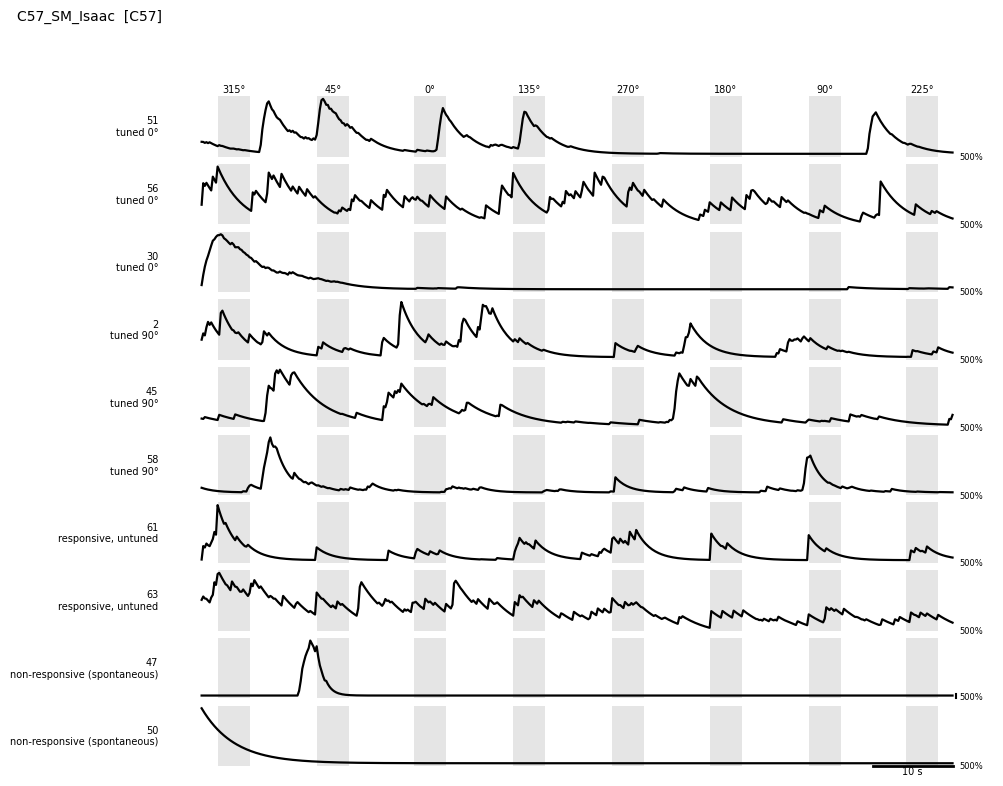

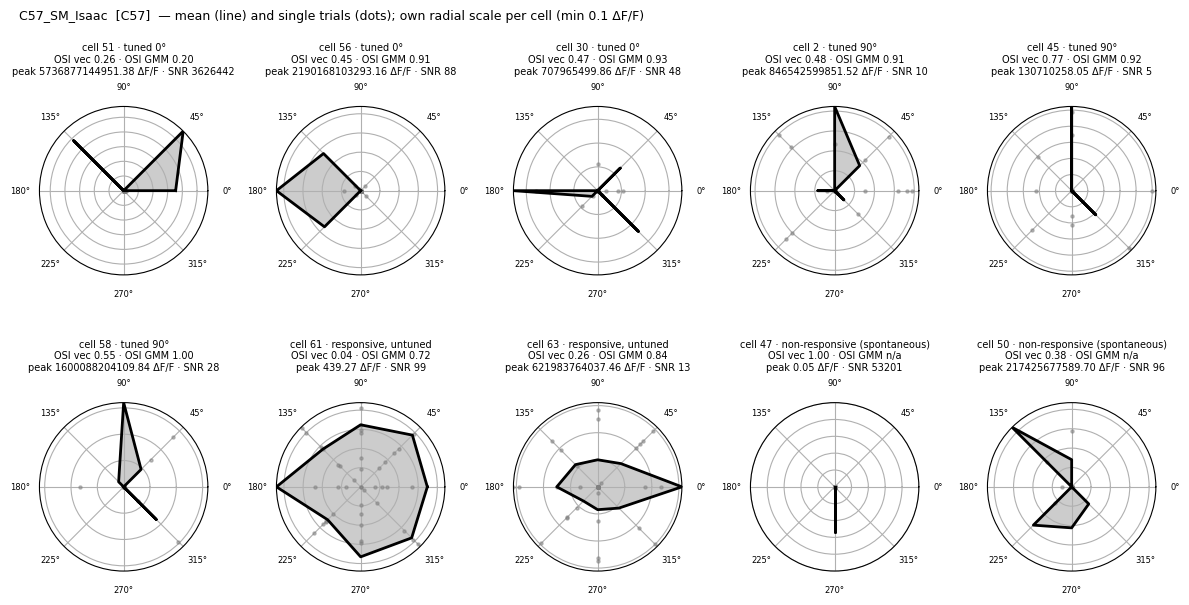

  BTBR_R2_060725: block = stimuli 0-7, angles [270, 45, 0, 225, 180, 315, 90, 135]


,neuron,tag,tier,osi_vec,osi_gmm,pref_ori,peak_dff,snr,reliab,hits_in_block,z_gray_block
0,92,tuned 0°,0,0.63,0.99,8.99,5.956227e+09,128.04,0.8,5,420.15
1,170,tuned 0°,0,0.77,0.44,171.96,5.328873e+11,53.53,0.6,3,131.97
2,183,tuned 0°,0,0.63,1.00,22.05,1.262261e+09,26.93,0.8,5,59.75
3,141,tuned 90°,1,0.49,0.93,81.43,1.200360e+12,86.29,1.0,1,199.20
4,137,tuned 90°,1,0.43,0.91,97.84,7.683458e+11,54.56,0.7,7,414.72
5,176,tuned 90°,1,0.78,0.44,90.00,3.462289e+05,1.39,0.4,2,65.12
6,96,"responsive, untuned",0,0.18,0.98,52.54,4.874954e+11,1007.94,0.5,4,9684.92
7,4,"responsive, untuned",0,0.11,0.20,110.16,2.188959e+09,210.27,0.8,3,286.66
8,166,non-responsive (spontaneous),0,0.71,NaN,156.79,2.300000e+00,1.71,0.3,0,38.86
9,46,non-responsive (spontaneous),0,0.33,NaN,180.00,4.366000e+01,0.53,0.1,0,8.15


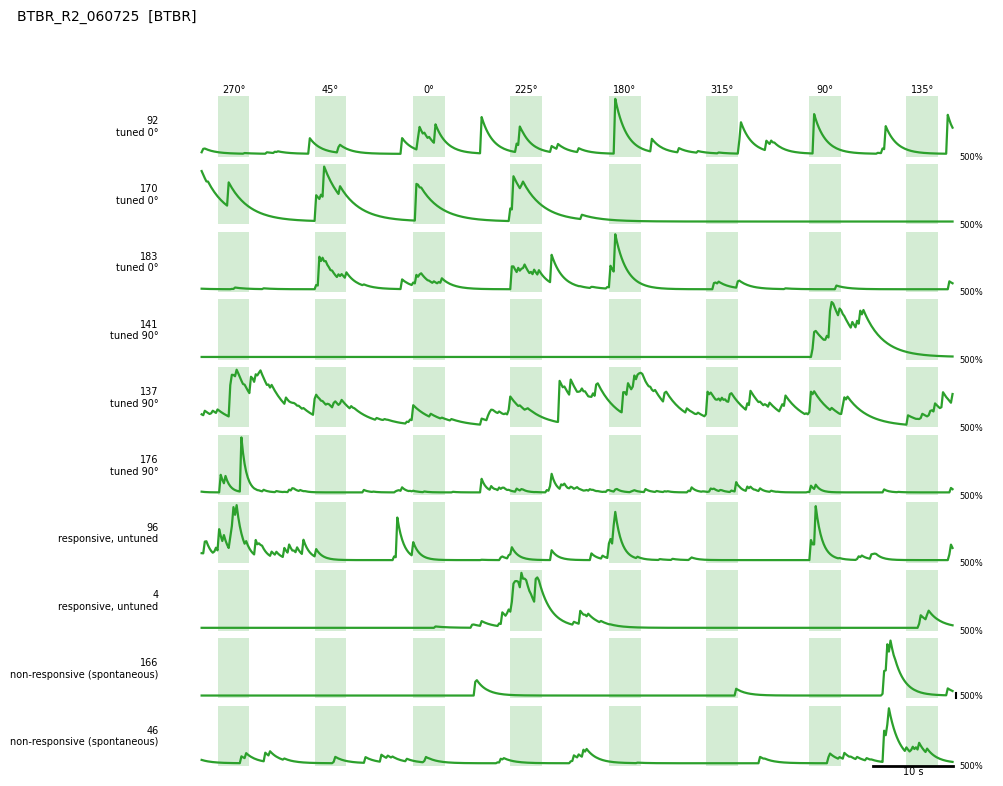

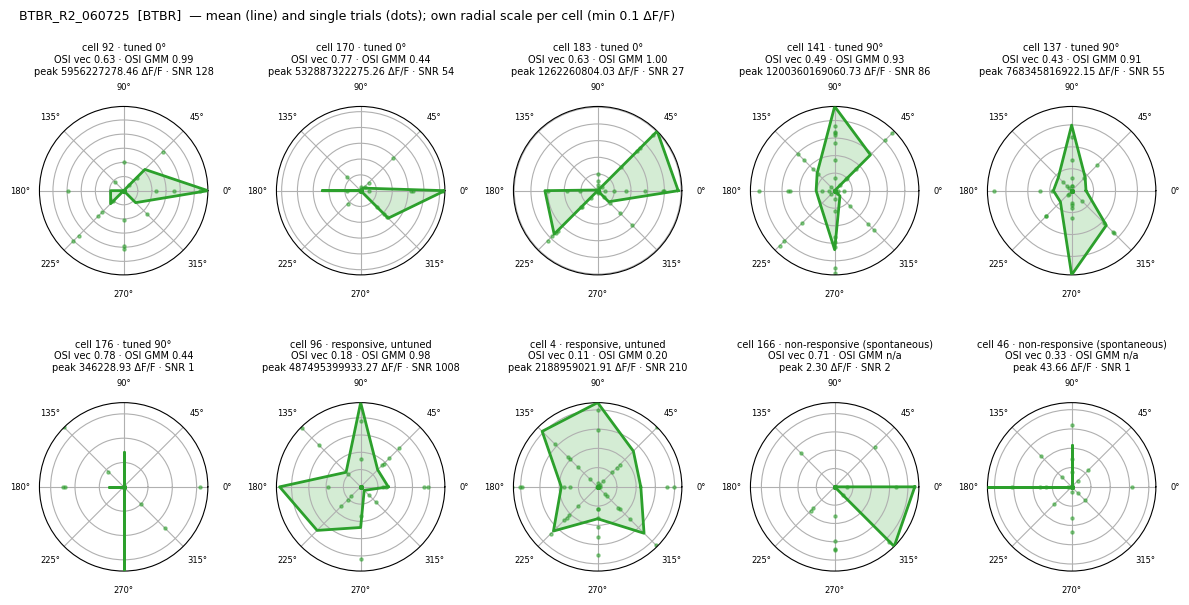

In [21]:
# ── 10 example neurons that clearly fire: raw traces over one block + polar tuning ──
# Needs session_data (cell 1) and animal_data (section 7).
import matplotlib.pyplot as plt

# Composition of the 10 cells
N_TUNED_A, N_TUNED_B, N_UNTUNED, N_NONRESP = 3, 3, 2, 2
ORI_A, ORI_B    = 0, 90     # orientations (deg, mod 180); must exist in the stimulus set
ORI_TOL         = 22.5      # preferred orientation within this of A / B counts as tuned to it (deg)

# "Fires" = evoked ΔF/F above MIN_SNR × the neuron's baseline noise (MAD of pre-stimulus frames)
MIN_SNR         = 5
TUNED_MIN_OSI   = 0.6       # strict tier for tuned cells (relaxed automatically if not enough are found)
MIN_RELIABILITY = 0.6       # strict tier: fraction of trials at the best angle with response > 3 × noise
UNTUNED_MAX_OSI = 0.3       # strict tier for "responsive, untuned"
DECAY_FR        = 10        # frames after stimulus offset not counted as gray (indicator decay)

# Block = consecutive stimuli, in presentation order
BLOCK_START = None          # None = the window with the most distinct angles; or an index
BLOCK_SIZE  = None          # None = one stimulus per angle (8); len(all_onsets) = whole session
PAD_S       = 2             # seconds shown before/after the block
SHARED_SCALE = False        # False: each row scaled to its own amplitude (with its own scale bar)
EXAMPLE_ANIMAL = {'C57': None, 'BTBR': None}    # None = first animal of the genotype

R_MIN = 0.1                 # smallest radial range in the polar plots (ΔF/F)
TRACE_LW = 1.6              # line width of the raw traces
SHOW_ANGLE_LABELS = True    # angle text above the first row (turn off if you add the gratings there)
GENO_STYLE = {              # trace / shading colours per genotype
    'C57':  {'trace': 'k',       'shade': '0.5',     'alpha': 0.20},
    'BTBR': {'trace': '#2ca02c', 'shade': '#2ca02c', 'alpha': 0.20},
}


def ori_dist(a, b):
    """Circular distance between orientations (deg, period 180)."""
    return np.abs((a - b + 90) % 180 - 90)


def trial_responses(dff, onsets_by_angle):
    """{angle: (n_trials, N)}: mean ΔF/F in the stimulus window minus the pre-stimulus mean."""
    out = {}
    for a, oo in onsets_by_angle.items():
        out[a] = np.array([dff[o:o + STIM_FRAMES].mean(axis=0) - dff[o - FRAMES_BEFORE:o].mean(axis=0)
                           for o in oo if o - FRAMES_BEFORE >= 0 and o + STIM_FRAMES <= len(dff)])
    return out


def orientation_stats(mean_resp, angs):
    """Vector-sum orientation selectivity (0-1) and preferred orientation (deg, 0-180)."""
    R   = np.clip(mean_resp, 0, None)
    v   = (R * np.exp(1j * np.deg2rad(2 * np.array(angs)))[:, None]).sum(axis=0)
    tot = R.sum(axis=0)
    osi = np.where(tot > 0, np.abs(v) / np.where(tot > 0, tot, 1), 0.0)
    return osi, (np.rad2deg(np.angle(v)) / 2) % 180


def pick_block(aid):
    s      = session_data[aid]
    on     = s['all_onsets']
    ang_of = {o: a for a, oo in s['onsets_by_angle'].items() for o in oo}
    seq    = [ang_of[o] for o in on]
    bs     = BLOCK_SIZE or len(s['onsets_by_angle'])
    if BLOCK_START is None:
        st = int(np.argmax([len(set(seq[i:i + bs])) for i in range(len(on) - bs + 1)]))
    else:
        st = BLOCK_START
    blk = on[st:st + bs]
    print(f'  {aid}: block = stimuli {st}-{st + len(blk) - 1}, angles {[ang_of[o] for o in blk]}')
    return blk, [ang_of[o] for o in blk]


def select_examples(aid, blk, blk_angles):
    s    = session_data[aid]
    dff  = s['dff']
    T    = len(dff)
    tr   = trial_responses(dff, s['onsets_by_angle'])
    angs = sorted(tr)
    if not any(ori_dist(a, ORI_A) == 0 for a in angs) or not any(ori_dist(a, ORI_B) == 0 for a in angs):
        raise ValueError(f'ORI_A={ORI_A} / ORI_B={ORI_B} not in the stimulus set {angs}')

    mean_resp = np.array([tr[a].mean(axis=0) for a in angs])          # (n_angles, N)
    N         = mean_resp.shape[1]
    osi, pref = orientation_stats(mean_resp, angs)
    peak      = mean_resp.max(axis=0)
    resp      = np.zeros(N, bool)
    resp[s['responsive']] = True

    # Baseline noise: MAD of the pre-stimulus frames pooled over all trials
    base  = np.concatenate([dff[o - FRAMES_BEFORE:o] for o in s['all_onsets'] if o >= FRAMES_BEFORE])
    noise = np.maximum(1.4826 * np.median(np.abs(base - np.median(base, axis=0)), axis=0), 1e-6)
    snr   = peak / noise
    frac  = np.array([(tr[a] > 3 * noise).mean(axis=0) for a in angs])
    rel   = frac[mean_resp.argmax(axis=0), np.arange(N)]              # reliability at the best angle

    # What the neuron does inside the block that will be drawn
    ab   = np.array(blk_angles)
    Rb   = np.array([dff[o:o + STIM_FRAMES].mean(axis=0) - dff[o - FRAMES_BEFORE:o].mean(axis=0) for o in blk])
    hit  = Rb > 3 * noise                                              # (n_block_stimuli, N)
    n_hits    = hit.sum(axis=0)
    hit_pref  = np.array([hit[ori_dist(ab, pref[n]) <= ORI_TOL, n].any() for n in range(N)])

    pad         = int(PAD_S * SAMPLING_RATE)
    start, stop = max(0, blk[0] - pad), min(T, blk[-1] + STIM_FRAMES + pad)
    in_stim     = np.zeros(T, bool)
    for o in s['all_onsets']:
        in_stim[o:o + STIM_FRAMES + DECAY_FR] = True
    seg    = dff[start:stop][~in_stim[start:stop]]                     # gray frames inside the window
    z_gray = (seg.max(axis=0) - np.median(seg, axis=0)) / noise        # spontaneous transients in the block

    def rank(mask, key, desc=True):
        idx = np.where(mask)[0]
        o   = np.argsort(key[idx])
        return idx[o[::-1]] if desc else idx[o]

    def tuned_tiers(ori):
        b = resp & hit_pref & (ori_dist(pref, ori) <= ORI_TOL)
        return [rank(b & (osi >= TUNED_MIN_OSI) & (rel >= MIN_RELIABILITY) & (snr >= MIN_SNR), snr),
                rank(b & (osi >= 0.4) & (rel >= 0.4), snr),
                rank(b, snr * osi)]

    bu = resp & (n_hits >= 3)                                          # fires to several block stimuli
    untuned_tiers = [rank(bu & (osi < UNTUNED_MAX_OSI) & (snr >= MIN_SNR), snr),
                     rank(bu & (osi < 0.5), snr),
                     rank(bu, osi, desc=False)]

    bn = ~resp                                                         # not stimulus-locked, but active
    nonresp_tiers = [rank(bn & (snr < MIN_SNR) & (n_hits <= 1) & (z_gray >= MIN_SNR), z_gray),
                     rank(bn & (n_hits <= 1), z_gray),
                     rank(bn, z_gray)]

    groups = [(f'tuned {ORI_A}°', N_TUNED_A, tuned_tiers(ORI_A)),
              (f'tuned {ORI_B}°', N_TUNED_B, tuned_tiers(ORI_B)),
              ('responsive, untuned', N_UNTUNED, untuned_tiers),
              ('non-responsive (spontaneous)', N_NONRESP, nonresp_tiers)]

    osi_gmm = animal_data[aid]['osi_df'].set_index('neuron')['OSI']
    info, used = [], set()
    for tag, k, tiers in groups:
        got = []
        for t_i, cand in enumerate(tiers):
            for c in cand:
                c = int(c)
                if c not in used and c not in [g[0] for g in got]:
                    got.append((c, t_i))
                if len(got) == k:
                    break
            if len(got) == k:
                break
        if len(got) < k:
            print(f'  {aid}: only {len(got)}/{k} neurons found for "{tag}"')
        for n, t_i in got:
            used.add(n)
            info.append({'neuron': n, 'tag': tag, 'tier': t_i,
                         'osi_vec': osi[n], 'osi_gmm': osi_gmm.get(n, np.nan), 'pref_ori': pref[n],
                         'peak_dff': peak[n], 'snr': snr[n], 'reliab': rel[n],
                         'hits_in_block': int(n_hits[n]), 'z_gray_block': z_gray[n]})
    return info


def nice_bar(span):
    """Scale-bar length (ΔF/F): the largest of a few round values that is <= span/2."""
    return max([b for b in (0.05, 0.1, 0.2, 0.5, 1, 2, 5) if b <= span / 2] or [0.05])


def plot_block_traces(aid, info, blk, blk_angles):
    s   = session_data[aid]
    dff = s['dff']
    T   = len(dff)
    pad         = int(PAD_S * SAMPLING_RATE)
    start, stop = max(0, blk[0] - pad), min(T, blk[-1] + STIM_FRAMES + pad)
    t           = np.arange(start, stop) / SAMPLING_RATE
    traces      = np.array([dff[start:stop, d['neuron']] for d in info])
    spans       = traces.max(axis=1) - traces.min(axis=1)
    if SHARED_SCALE:
        spans = np.full(len(info), spans.max())

    st  = GENO_STYLE[s['genotype']]
    fig, axes = plt.subplots(len(info), 1, figsize=(10.5, 0.75 * len(info) + 1.2), sharex=True)
    for ax, d, y, sp_ in zip(axes, info, traces, spans):
        for o in blk:
            ax.axvspan(o / SAMPLING_RATE, (o + STIM_FRAMES) / SAMPLING_RATE,
                       color=st['shade'], alpha=st['alpha'], lw=0)
        ax.plot(t, y, color=st['trace'], lw=TRACE_LW)
        ax.set_ylim(y.min() - 0.05 * sp_, y.min() + 1.05 * sp_)
        ax.set_ylabel(f"{d['neuron']}\n{d['tag']}", rotation=0, ha='right', va='center', fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)
        if not SHARED_SCALE:                                           # per-row ΔF/F scale bar
            b, lo = nice_bar(sp_), ax.get_ylim()[0]
            ax.plot([t[-1] + 0.4] * 2, [lo, lo + b], 'k', lw=1.5, clip_on=False)
            ax.text(t[-1] + 0.8, lo + b / 2, f'{b * 100:.0f}%', fontsize=6, va='center')

    if SHOW_ANGLE_LABELS:                                              # angle labels on top
        for o, a in zip(blk, blk_angles):
            axes[0].text((o + STIM_FRAMES / 2) / SAMPLING_RATE, 1.03, f'{a}°',
                         transform=axes[0].get_xaxis_transform(), ha='center', va='bottom', fontsize=7)

    ylo = axes[-1].get_ylim()[0]                                       # time bar (+ shared ΔF/F bar)
    axes[-1].plot([t[-1] - 10, t[-1]], [ylo, ylo], 'k', lw=2, clip_on=False)
    axes[-1].text(t[-1] - 5, ylo, '10 s', ha='center', va='top', fontsize=7)
    if SHARED_SCALE:
        axes[-1].plot([t[-1], t[-1]], [ylo, ylo + 0.1], 'k', lw=2, clip_on=False)
        axes[-1].text(t[-1] + 0.3, ylo + 0.05, '10%', ha='left', va='center', fontsize=7)

    fig.suptitle(f"{aid}  [{s['genotype']}]", fontsize=10, x=0.02, ha='left')
    fig.subplots_adjust(left=0.16, right=0.95, hspace=0.12)
    fig.savefig(OUTPUT_DIR / f'{aid}_block_traces.svg', format='svg', bbox_inches='tight')
    plt.show()


def plot_polar(aid, info):
    s    = session_data[aid]
    tr   = trial_responses(s['dff'], s['onsets_by_angle'])
    angs = sorted(tr)
    th   = np.deg2rad(angs + [angs[0]])                                 # closed loop
    st   = GENO_STYLE[s['genotype']]

    n_cols = 5
    n_rows = int(np.ceil(len(info) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.4 * n_cols, 3.1 * n_rows),
                             subplot_kw={'projection': 'polar'})
    axes = np.atleast_1d(axes).flatten()
    for ax, d in zip(axes, info):
        n       = d['neuron']
        gmm_txt = 'n/a' if np.isnan(d['osi_gmm']) else f"{d['osi_gmm']:.2f}"
        mean    = np.clip([tr[a][:, n].mean() for a in angs], 0, None)  # negative responses shown as 0
        for a in angs:
            ax.scatter(np.full(len(tr[a]), np.deg2rad(a)), np.clip(tr[a][:, n], 0, None),
                       s=5, color=st['shade'], alpha=0.5, zorder=2)
        ax.plot(th, np.append(mean, mean[0]), color=st['trace'], lw=2, zorder=3)
        ax.fill(th, np.append(mean, mean[0]), color=st['trace'], alpha=0.2, zorder=1)
        ax.set_xticks(np.deg2rad(angs))
        ax.set_xticklabels([f'{a}°' for a in angs], fontsize=6)
        ax.set_ylim(0, max(mean.max(), R_MIN))
        ax.set_yticklabels([])
        ax.set_title(f"cell {n} · {d['tag']}\nOSI vec {d['osi_vec']:.2f} · OSI GMM {gmm_txt}\n"
                     f"peak {d['peak_dff']:.2f} ΔF/F · SNR {d['snr']:.0f}", fontsize=7)
    for ax in axes[len(info):]:
        ax.set_visible(False)
    fig.suptitle(f"{aid}  [{s['genotype']}]  — mean (line) and single trials (dots); own radial scale per cell (min 0.1 ΔF/F)",
                 fontsize=9, x=0.02, ha='left')
    plt.tight_layout(h_pad=2.5)
    fig.savefig(OUTPUT_DIR / f'{aid}_polar_tuning.svg', format='svg', bbox_inches='tight')
    plt.show()


for g in GENO_ORDER:
    aid             = EXAMPLE_ANIMAL.get(g) or next(a for a, d in session_data.items() if d['genotype'] == g)
    blk, blk_angles = pick_block(aid)
    info            = select_examples(aid, blk, blk_angles)
    display(pd.DataFrame(info).round(2))
    plot_block_traces(aid, info, blk, blk_angles)
    plot_polar(aid, info)

In [22]:
# ── Spontaneous events/min from the separate recordings (pre / post) ──────────
# Needs cell 1 (load_traces), cell 3 (binarize_traces, events_per_min), detect_genotype (section 2).
SPON_ROOT = r'D:\AL-205\Nicole\Calcio_raw\Espontaneo'         # <── change if needed
SPON_KEYWORDS = {'pre': 'espontaneopre', 'post': 'espontaneopost'}   # substring of the CSV file name


def discover_spontaneous(root):
    """Looks under <root>/<genotype folder>/... for CSVs whose name contains the pre / post keyword.
    animal_id = first subfolder under the genotype folder (or the file-name prefix if files sit directly there)."""
    root, rows = Path(root), []
    for group in sorted(p for p in root.iterdir() if p.is_dir()):
        geno = detect_genotype(group.name)                      # raises if the folder is not BTBR / C57
        for f in sorted(group.rglob('*.csv')):
            for cond, kw in SPON_KEYWORDS.items():
                if kw in f.name.lower():
                    parts  = f.relative_to(group).parts
                    animal = parts[0] if len(parts) > 1 else f.stem.lower().split(kw)[0].strip('_- .') or f.stem
                    rows.append({'genotype': geno, 'animal_id': animal, 'condition': cond, 'file': f})
    df = pd.DataFrame(rows)
    if df.empty:
        raise FileNotFoundError(f'No CSV with {list(SPON_KEYWORDS.values())} under {root}')
    dup = df[df.duplicated(['genotype', 'animal_id', 'condition'], keep=False)]
    if len(dup):
        raise ValueError('More than one file per animal/condition:\n' + dup.to_string())
    return df


spon_files = discover_spontaneous(SPON_ROOT)

rows, info = [], []
for r in spon_files.itertuples():
    traces = load_traces(r.file)                                # (T, N) raw fluorescence
    binary = binarize_traces(traces, BINARIZE_THR)              # mean + 0.5 SD of the whole recording
    rate   = events_per_min(binary, np.ones(len(traces), bool)) # 0→1 transitions per minute
    rows.append(pd.DataFrame({'genotype': r.genotype, 'animal_id': r.animal_id, 'condition': r.condition,
                              'neuron': np.arange(traces.shape[1]), 'ev_min': rate}))
    info.append({'genotype': r.genotype, 'animal_id': r.animal_id, 'condition': r.condition,
                 'neurons': traces.shape[1], 'minutes': round(len(traces) / SAMPLING_RATE / 60, 1),
                 'file': r.file.name})

spon_df = pd.concat(rows, ignore_index=True)
spon_df.to_csv(OUTPUT_DIR / 'spontaneous_event_rates.csv', index=False)
display(pd.DataFrame(info))                                     # check that files were matched as you expect

both = set(spon_df['animal_id']) & set(session_data)
print(f'{spon_df["animal_id"].nunique()} animals with spontaneous recordings; '
      f'{len(both)} share the ID with a stimulation animal: {sorted(both)}')
display(spon_df.groupby(['genotype', 'condition'])['ev_min'].agg(['median', 'mean', 'size']).round(2))

,genotype,animal_id,condition,neurons,minutes,file
0,BTBR,btbrl1030825,post,60,7.9,BTBRL1030825_espontaneoPostOryDir_12_12_25_Ctr...
1,BTBR,btbrl1030825,pre,90,10.1,BTBRL1030825_espontaneopre_12_12_25_Ctraces.csv
2,BTBR,btbrr1_280825,post,106,10.1,BTBRR1_280825_espontaneoPostOryDir_12_12_25_Ct...
3,BTBR,btbrr1_280825,pre,80,10.0,BTBRR1_280825_espontaneopre_15_12_25_Ctraces.csv
4,C57,c57r1230825,post,53,10.1,C57R1230825_espontaneopost_Ctraces.csv
5,C57,c57r1230825,pre,47,5.4,C57R1230825_espontaneopre_Ctraces.csv
6,C57,c57r3230825,post,183,10.1,C57R3230825_espontaneopost_Ctraces.csv
7,C57,c57r3230825,pre,209,10.1,C57R3230825_espontaneopre_Ctraces.csv


4 animals with spontaneous recordings; 0 share the ID with a stimulation animal: []


median  mean  size
genotype condition                    
BTBR     post         3.58  4.07   166
         pre          4.98  5.01   170
C57      post         3.71  4.22   236
         pre          5.63  5.90   256

  C57_SM_Isaac: block = stimuli 0-7, angles [315, 45, 0, 135, 270, 180, 90, 225]
  BTBR_R2_060725: block = stimuli 0-7, angles [270, 45, 0, 225, 180, 315, 90, 135]


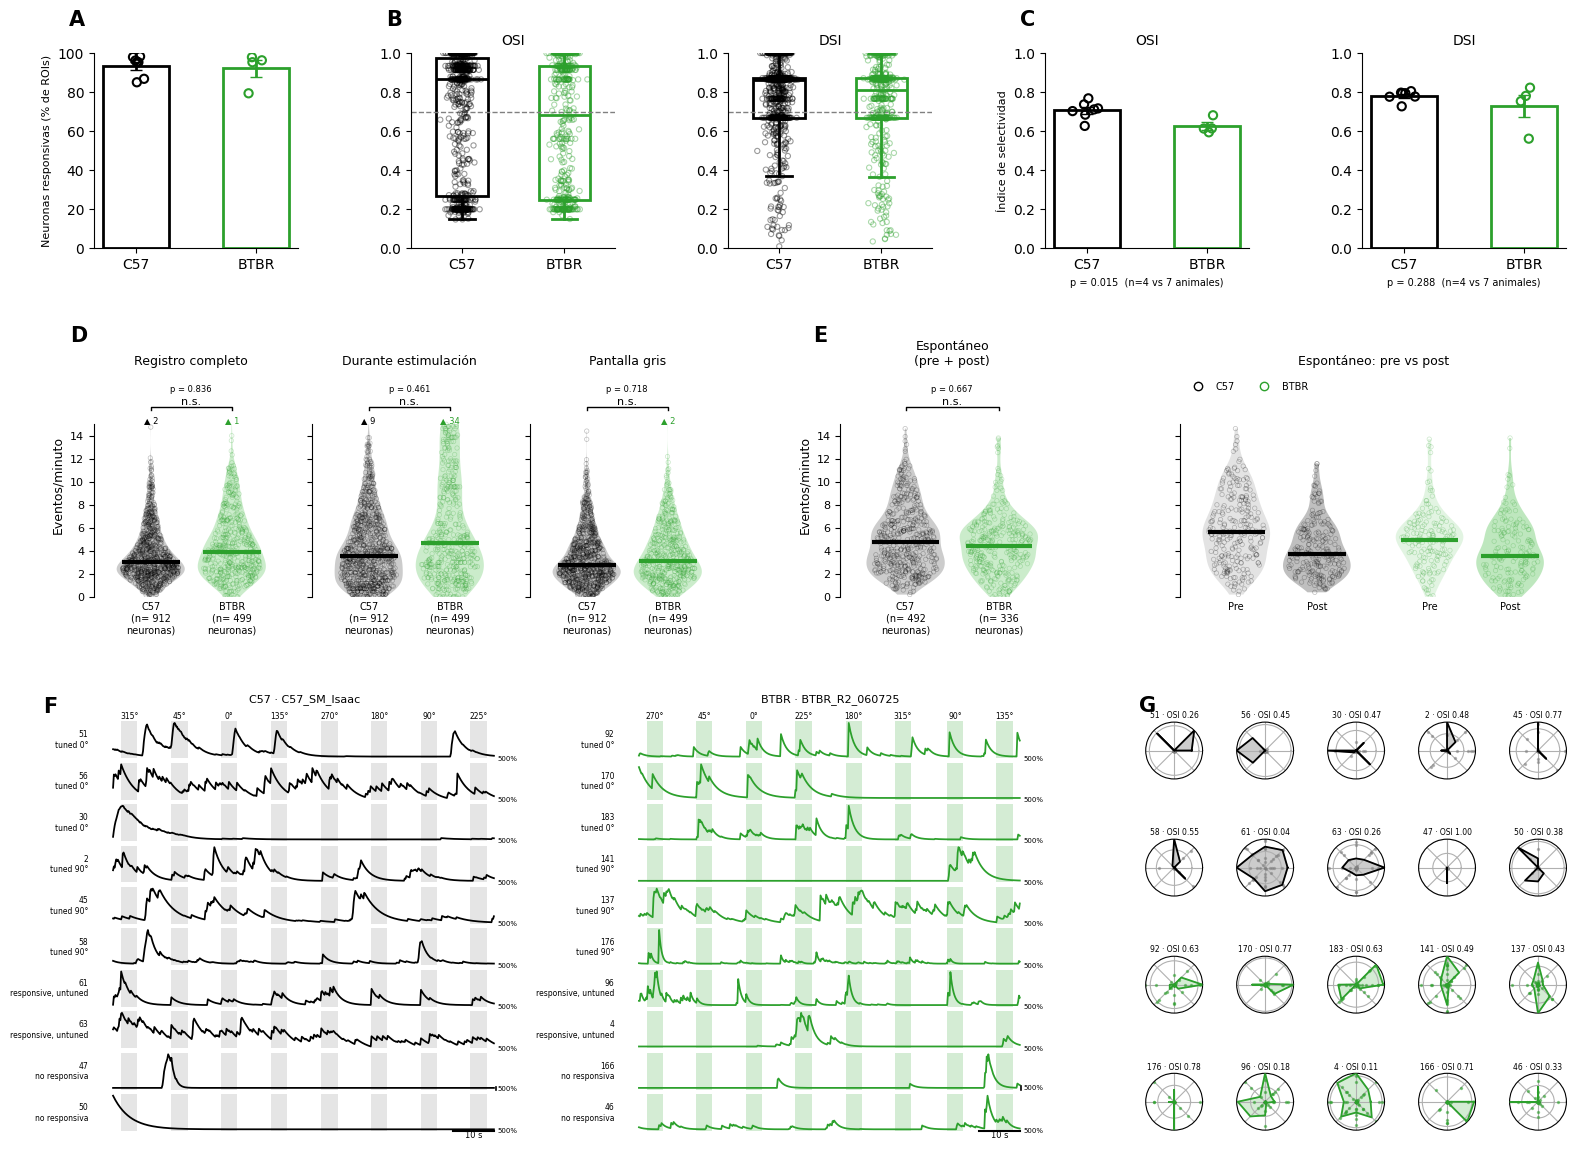

Spontaneous events/min — permutation tests on per-animal means
  BTBR vs C57, pre : p = 0.667  (n=2 vs 2 animals)
  BTBR vs C57, post: p = 1.000  (n=2 vs 2 animals)
  C57 pre vs post (paired, exact sign-flip): p = 0.500  (n=2 animals; smallest attainable p = 0.500)
  BTBR pre vs post (paired, exact sign-flip): p = 0.500  (n=2 animals; smallest attainable p = 0.500)


In [23]:
# ── Figure 1: all panels in one figure ────────────────────────────────────────
# Needs: summary_df, consolidated (section 8), permutation_test (section 10, fixed version),
#        session_data / animal_data, fig_rates + stars (events cell), select_examples / pick_block /
#        trial_responses / nice_bar / GENO_STYLE / constants (example-neurons cell), spon_df (spontaneous cell).
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from itertools import product
from scipy.stats import gaussian_kde

GENOS      = ['C57', 'BTBR']
PAL        = {'C57': '#000000', 'BTBR': '#2ca02c'}
FIG_SIZE   = (19, 14)
YMAX       = 15          # events/min axis cut (shared by every events panel)
JITTER_FRAC = 0.83
LETTERS    = True


def swarm_violin(ax, x, vals, sty, rng, half_width=0.42, ymax=None, fill_alpha=0.4):
    """Filled violin + dots inside it + thick median. Density/median use all values; only <= ymax is drawn."""
    vals  = np.asarray(vals, float)
    hi    = vals.max() if ymax is None else min(vals.max(), ymax)
    shown = vals[vals <= hi]
    if len(vals) > 2 and np.ptp(vals) > 0 and vals.min() < hi:
        ys   = np.linspace(vals.min(), hi, 200)
        dens = gaussian_kde(vals)(ys)
        dens = dens / dens.max() * half_width
        ax.fill_betweenx(ys, x - dens, x + dens, facecolor=sty['fill'], alpha=fill_alpha, edgecolor='none', zorder=1)
        spread = np.interp(shown, ys, dens)
    else:
        spread = np.full(len(shown), 0.05)
    ax.scatter(x + rng.uniform(-1, 1, len(shown)) * spread * JITTER_FRAC, shown, s=10,
               facecolors='none', edgecolors=sty['dot'], linewidths=0.5, alpha=0.25, zorder=2)
    med = np.median(vals)
    if ymax is None or med <= ymax:
        ax.hlines(med, x - 0.85 * half_width, x + 0.85 * half_width, color=sty['line'], lw=3, zorder=4)
    else:
        ax.text(x, ymax, f'mediana {med:.1f}', ha='center', va='top', fontsize=6, color=sty['line'])
    if len(vals) - len(shown):
        ax.text(x, hi, f'▲ {len(vals) - len(shown)}', ha='center', va='bottom', fontsize=6, color=sty['line'])


def signflip_test(diffs):
    """Exact paired test (sign flips of per-animal differences), two-tailed."""
    d   = np.asarray(diffs, float)
    obs = abs(d.mean())
    sgn = np.array(list(product([1, -1], repeat=len(d))))
    return float(np.mean(np.abs((sgn * d).mean(axis=1)) >= obs - 1e-12 * max(1.0, obs)))


def animal_p(df, col):
    am = df.groupby(['genotype', 'animal_id'])[col].mean().reset_index()
    b, c = (am.loc[am['genotype'] == g, col].values for g in ('BTBR', 'C57'))
    return permutation_test(b, c) if len(b) >= 2 and len(c) >= 2 else None


def bracket(ax, x0, x1, p, top=YMAX):
    if p is None:
        return
    y = top * 1.10
    ax.plot([x0, x0, x1, x1], [y * 0.985, y, y, y * 0.985], color='k', lw=1)
    ax.text((x0 + x1) / 2, y, stars(p), ha='center', va='bottom', fontsize=11 if p < 0.05 else 8)
    ax.text((x0 + x1) / 2, y * 1.07, f'p = {p:.3f}', ha='center', va='bottom', fontsize=6)


def violin_axes(ax, positions, labels, first=True):
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_ylim(0, YMAX * 1.3)
    ax.set_yticks(np.arange(0, YMAX + 1, 2))
    ax.spines['left'].set_bounds(0, YMAX)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', labelleft=first, labelsize=8)


def letter(ax, s):
    if LETTERS:
        ax.text(-0.12, 1.12, s, transform=ax.transAxes, fontsize=15, fontweight='bold', va='bottom')


# ── panel builders ────────────────────────────────────────────────────────────
def panel_pct(ax):
    rj = np.random.default_rng(0)
    for i, g in enumerate(GENOS):
        v = summary_df.loc[summary_df['genotype'] == g, 'pct_responsive'].values
        ax.bar(i, v.mean(), width=0.55, facecolor='none', edgecolor=PAL[g], linewidth=2)
        ax.errorbar(i, v.mean(), yerr=sem(v) if len(v) > 1 else 0, color=PAL[g], capsize=4, lw=2)
        ax.scatter(i + rj.normal(0, 0.05, len(v)), v, s=35, facecolors='none', edgecolors=PAL[g], linewidths=1.5, zorder=3)
    ax.set_xticks(range(2)); ax.set_xticklabels(GENOS)
    ax.set_ylim(0, 100); ax.set_ylabel('Neuronas responsivas (% de ROIs)', fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)


def panel_box(ax, metric):
    rj = np.random.default_rng(1)
    groups = [consolidated.loc[consolidated['genotype'] == g, metric].values for g in GENOS]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5, showfliers=False,
                    boxprops=dict(facecolor='none', linewidth=2), whiskerprops=dict(linewidth=2),
                    capprops=dict(linewidth=2), medianprops=dict(linewidth=2))
    for i, g in enumerate(GENOS):
        for k in ('boxes', 'medians'):
            bp[k][i].set_edgecolor(PAL[g]) if k == 'boxes' else bp[k][i].set_color(PAL[g])
        for k in ('whiskers', 'caps'):
            bp[k][2 * i].set_color(PAL[g]); bp[k][2 * i + 1].set_color(PAL[g])
        ax.scatter(rj.normal(i + 1, 0.06, len(groups[i])), groups[i], facecolors='none', edgecolors=PAL[g],
                   linewidths=0.8, s=14, alpha=0.4, zorder=3)
    ax.axhline(OSI_THRESH, ls='--', color='gray', lw=1)
    ax.set_xticks([1, 2]); ax.set_xticklabels(GENOS)
    ax.set_ylim(0, 1); ax.set_title(metric, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)


def panel_bar(ax, metric):
    rj = np.random.default_rng(2)
    am = consolidated.groupby(['genotype', 'animal_id'])[metric].mean().reset_index()
    for i, g in enumerate(GENOS):
        v = am.loc[am['genotype'] == g, metric].values
        ax.bar(i, v.mean(), width=0.55, facecolor='none', edgecolor=PAL[g], linewidth=2)
        ax.errorbar(i, v.mean(), yerr=sem(v) if len(v) > 1 else 0, color=PAL[g], capsize=4, lw=2)
        ax.scatter(i + rj.normal(0, 0.05, len(v)), v, s=35, facecolors='none', edgecolors=PAL[g], linewidths=1.5, zorder=3)
    b, c = (am.loc[am['genotype'] == g, metric].values for g in ('BTBR', 'C57'))
    if len(b) >= 2 and len(c) >= 2:
        ax.set_xlabel(f'p = {permutation_test(b, c):.3f}  (n={len(b)} vs {len(c)} animales)', fontsize=7)
    ax.set_xticks(range(2)); ax.set_xticklabels(GENOS)
    ax.set_ylim(0, 1); ax.set_title(metric, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)


def panel_events(ax, w, title, first):
    rg = np.random.default_rng({'total': 10, 'stim': 11, 'gray': 12}[w])
    col = f'ev_min_{w}'
    for i, g in enumerate(GENOS):
        swarm_violin(ax, i, fig_rates.loc[fig_rates['genotype'] == g, col].values, STYLE[g], rg, ymax=YMAX)
    bracket(ax, 0, 1, animal_p(fig_rates, col))
    n = fig_rates['genotype'].value_counts()
    violin_axes(ax, [0, 1], [f'{g}\n(n= {n[g]}\nneuronas)' for g in GENOS], first)
    ax.set_xlim(-0.7, 1.7); ax.set_title(title, fontsize=9)
    if first:
        ax.set_ylabel('Eventos/minuto', fontsize=9)


def panel_spont_global(ax):
    rg = np.random.default_rng(20)
    for i, g in enumerate(GENOS):
        swarm_violin(ax, i, spon_df.loc[spon_df['genotype'] == g, 'ev_min'].values, STYLE[g], rg, ymax=YMAX)
    bracket(ax, 0, 1, animal_p(spon_df.rename(columns={'ev_min': 'v'}), 'v'))
    n = spon_df['genotype'].value_counts()
    violin_axes(ax, [0, 1], [f'{g}\n(n= {n[g]}\nneuronas)' for g in GENOS], True)
    ax.set_xlim(-0.7, 1.7); ax.set_title('Espontáneo\n(pre + post)', fontsize=9)
    ax.set_ylabel('Eventos/minuto', fontsize=9)


def panel_spont_prepost(ax):
    rg  = np.random.default_rng(21)
    pos = {('C57', 'pre'): 0, ('C57', 'post'): 1, ('BTBR', 'pre'): 2.4, ('BTBR', 'post'): 3.4}
    for (g, cond), x in pos.items():
        v = spon_df.loc[(spon_df['genotype'] == g) & (spon_df['condition'] == cond), 'ev_min'].values
        if len(v):
            swarm_violin(ax, x, v, STYLE[g], rg, ymax=YMAX, fill_alpha=0.22 if cond == 'pre' else 0.5)
    violin_axes(ax, list(pos.values()), ['Pre', 'Post', 'Pre', 'Post'], False)
    ax.set_xlim(-0.7, 4.1); ax.set_title('Espontáneo: pre vs post', fontsize=9)
    ax.legend(handles=[Line2D([0], [0], marker='o', mfc='none', mec=PAL[g], ls='', label=g) for g in GENOS],
              frameon=False, loc='upper left', fontsize=7, ncol=2)


def panel_traces(spec, aid, info, blk, blk_angles):
    dff = session_data[aid]['dff']
    T, st  = len(dff), GENO_STYLE[session_data[aid]['genotype']]
    pad    = int(PAD_S * SAMPLING_RATE)
    a0, a1 = max(0, blk[0] - pad), min(T, blk[-1] + STIM_FRAMES + pad)
    t      = np.arange(a0, a1) / SAMPLING_RATE
    tr     = np.array([dff[a0:a1, d['neuron']] for d in info])
    spans  = tr.max(axis=1) - tr.min(axis=1)
    sub    = spec.subgridspec(len(info), 1, hspace=0.12)
    axes   = []
    for r, (d, y, sp_) in enumerate(zip(info, tr, spans)):
        ax = fig.add_subplot(sub[r], sharex=axes[0] if axes else None)
        axes.append(ax)
        for o in blk:
            ax.axvspan(o / SAMPLING_RATE, (o + STIM_FRAMES) / SAMPLING_RATE, color=st['shade'], alpha=st['alpha'], lw=0)
        ax.plot(t, y, color=st['trace'], lw=TRACE_LW * 0.8)
        ax.set_ylim(y.min() - 0.05 * sp_, y.min() + 1.05 * sp_)
        ax.set_ylabel(f"{d['neuron']}\n{d['tag'].replace('non-responsive (spontaneous)', 'no responsiva')}",
                      rotation=0, ha='right', va='center', fontsize=5.5)
        ax.set_xticks([]); ax.set_yticks([])
        for spn in ax.spines.values():
            spn.set_visible(False)
        b, lo = nice_bar(sp_), ax.get_ylim()[0]
        ax.plot([t[-1] + 0.4] * 2, [lo, lo + b], 'k', lw=1.2, clip_on=False)
        ax.text(t[-1] + 0.8, lo + b / 2, f'{b * 100:.0f}%', fontsize=5, va='center')
    if SHOW_ANGLE_LABELS:
        for o, a in zip(blk, blk_angles):
            axes[0].text((o + STIM_FRAMES / 2) / SAMPLING_RATE, 1.03, f'{a}°',
                         transform=axes[0].get_xaxis_transform(), ha='center', va='bottom', fontsize=5.5)
    ylo = axes[-1].get_ylim()[0]
    axes[-1].plot([t[-1] - 10, t[-1]], [ylo, ylo], 'k', lw=1.5, clip_on=False)
    axes[-1].text(t[-1] - 5, ylo, '10 s', ha='center', va='top', fontsize=6)
    axes[0].set_title(f"{session_data[aid]['genotype']} · {aid}", fontsize=8, pad=14)
    return axes[0]


def panel_polar(spec, entries):
    sub = spec.subgridspec(2 * len(entries), 5, hspace=1.0, wspace=0.6)
    first = None
    for k, (aid, info) in enumerate(entries):
        s    = session_data[aid]
        tr   = trial_responses(s['dff'], s['onsets_by_angle'])
        angs = sorted(tr)
        th   = np.deg2rad(angs + [angs[0]])
        st   = GENO_STYLE[s['genotype']]
        for j, d in enumerate(info):
            ax = fig.add_subplot(sub[2 * k + j // 5, j % 5], projection='polar')
            first = first or ax
            n    = d['neuron']
            mean = np.clip([tr[a][:, n].mean() for a in angs], 0, None)
            for a in angs:
                ax.scatter(np.full(len(tr[a]), np.deg2rad(a)), np.clip(tr[a][:, n], 0, None),
                           s=2, color=st['shade'], alpha=0.5, zorder=2)
            ax.plot(th, np.append(mean, mean[0]), color=st['trace'], lw=1.3, zorder=3)
            ax.fill(th, np.append(mean, mean[0]), color=st['trace'], alpha=0.2, zorder=1)
            ax.set_xticks(np.deg2rad(angs)); ax.set_xticklabels([])
            ax.set_ylim(0, max(mean.max(), R_MIN)); ax.set_yticklabels([])
            ax.tick_params(pad=-2)
            ax.set_title(f"{n} · OSI {d['osi_vec']:.2f}", fontsize=5.5, pad=3)
    return first


# ── assemble ──────────────────────────────────────────────────────────────────
entries = []
for g in GENOS:
    aid = EXAMPLE_ANIMAL.get(g) or next(a for a, d in session_data.items() if d['genotype'] == g)
    blk, blk_angles = pick_block(aid)
    entries.append((aid, select_examples(aid, blk, blk_angles), blk, blk_angles))

fig   = plt.figure(figsize=FIG_SIZE)
outer = fig.add_gridspec(3, 1, height_ratios=[1, 1.15, 2.1], hspace=0.45)

row1 = outer[0].subgridspec(1, 5, wspace=0.55)
axA  = fig.add_subplot(row1[0]); panel_pct(axA)
axB1 = fig.add_subplot(row1[1]); panel_box(axB1, 'OSI')
axB2 = fig.add_subplot(row1[2]); panel_box(axB2, 'DSI')
axC1 = fig.add_subplot(row1[3]); panel_bar(axC1, 'OSI')
axC2 = fig.add_subplot(row1[4], sharey=axC1); panel_bar(axC2, 'DSI')
axC1.set_ylabel('Índice de selectividad', fontsize=8)
for a_, s_ in ((axA, 'A'), (axB1, 'B'), (axC1, 'C')):
    letter(a_, s_)

row2 = outer[1].subgridspec(1, 3, width_ratios=[3.1, 1.1, 1.9], wspace=0.28)
ev   = row2[0].subgridspec(1, 3, wspace=0.12)
axE  = []
for k, (w, ttl) in enumerate([('total', 'Registro completo'), ('stim', 'Durante estimulación'), ('gray', 'Pantalla gris')]):
    ax = fig.add_subplot(ev[k], sharey=axE[0] if axE else None)
    panel_events(ax, w, ttl, first=(k == 0)); axE.append(ax)
letter(axE[0], 'D')
axS1 = fig.add_subplot(row2[1], sharey=axE[0]); panel_spont_global(axS1)
axS2 = fig.add_subplot(row2[2], sharey=axE[0]); panel_spont_prepost(axS2)
letter(axS1, 'E')

row3 = outer[2].subgridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.25)
axF  = panel_traces(row3[0], *entries[0]); letter(axF, 'F')
panel_traces(row3[1], *entries[1])
axG  = panel_polar(row3[2], [(e[0], e[1]) for e in entries]); letter(axG, 'G')

fig.savefig(OUTPUT_DIR / 'figura1_composite.svg', format='svg', bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'figura1_composite.png', dpi=200, bbox_inches='tight')
plt.show()

# ── tests behind the spontaneous panels (unit = animal) ───────────────────────
sm = spon_df.groupby(['genotype', 'animal_id', 'condition'])['ev_min'].mean().unstack('condition').reset_index()
print('Spontaneous events/min — permutation tests on per-animal means')
for cond in ('pre', 'post'):
    b, c = (sm.loc[sm['genotype'] == g, cond].dropna().values for g in ('BTBR', 'C57'))
    if len(b) >= 2 and len(c) >= 2:
        print(f'  BTBR vs C57, {cond:4s}: p = {permutation_test(b, c):.3f}  (n={len(b)} vs {len(c)} animals)')
for g in GENOS:
    pp = sm.loc[sm['genotype'] == g].dropna(subset=['pre', 'post'])
    if len(pp) >= 2:
        print(f'  {g} pre vs post (paired, exact sign-flip): p = {signflip_test(pp["post"] - pp["pre"]):.3f}  '
              f'(n={len(pp)} animals; smallest attainable p = {2 / 2 ** len(pp):.3f})')

  C57_SM_Isaac: block = stimuli 0-7, angles [315, 45, 0, 135, 270, 180, 90, 225]
  BTBR_R2_060725: block = stimuli 0-7, angles [270, 45, 0, 225, 180, 315, 90, 135]


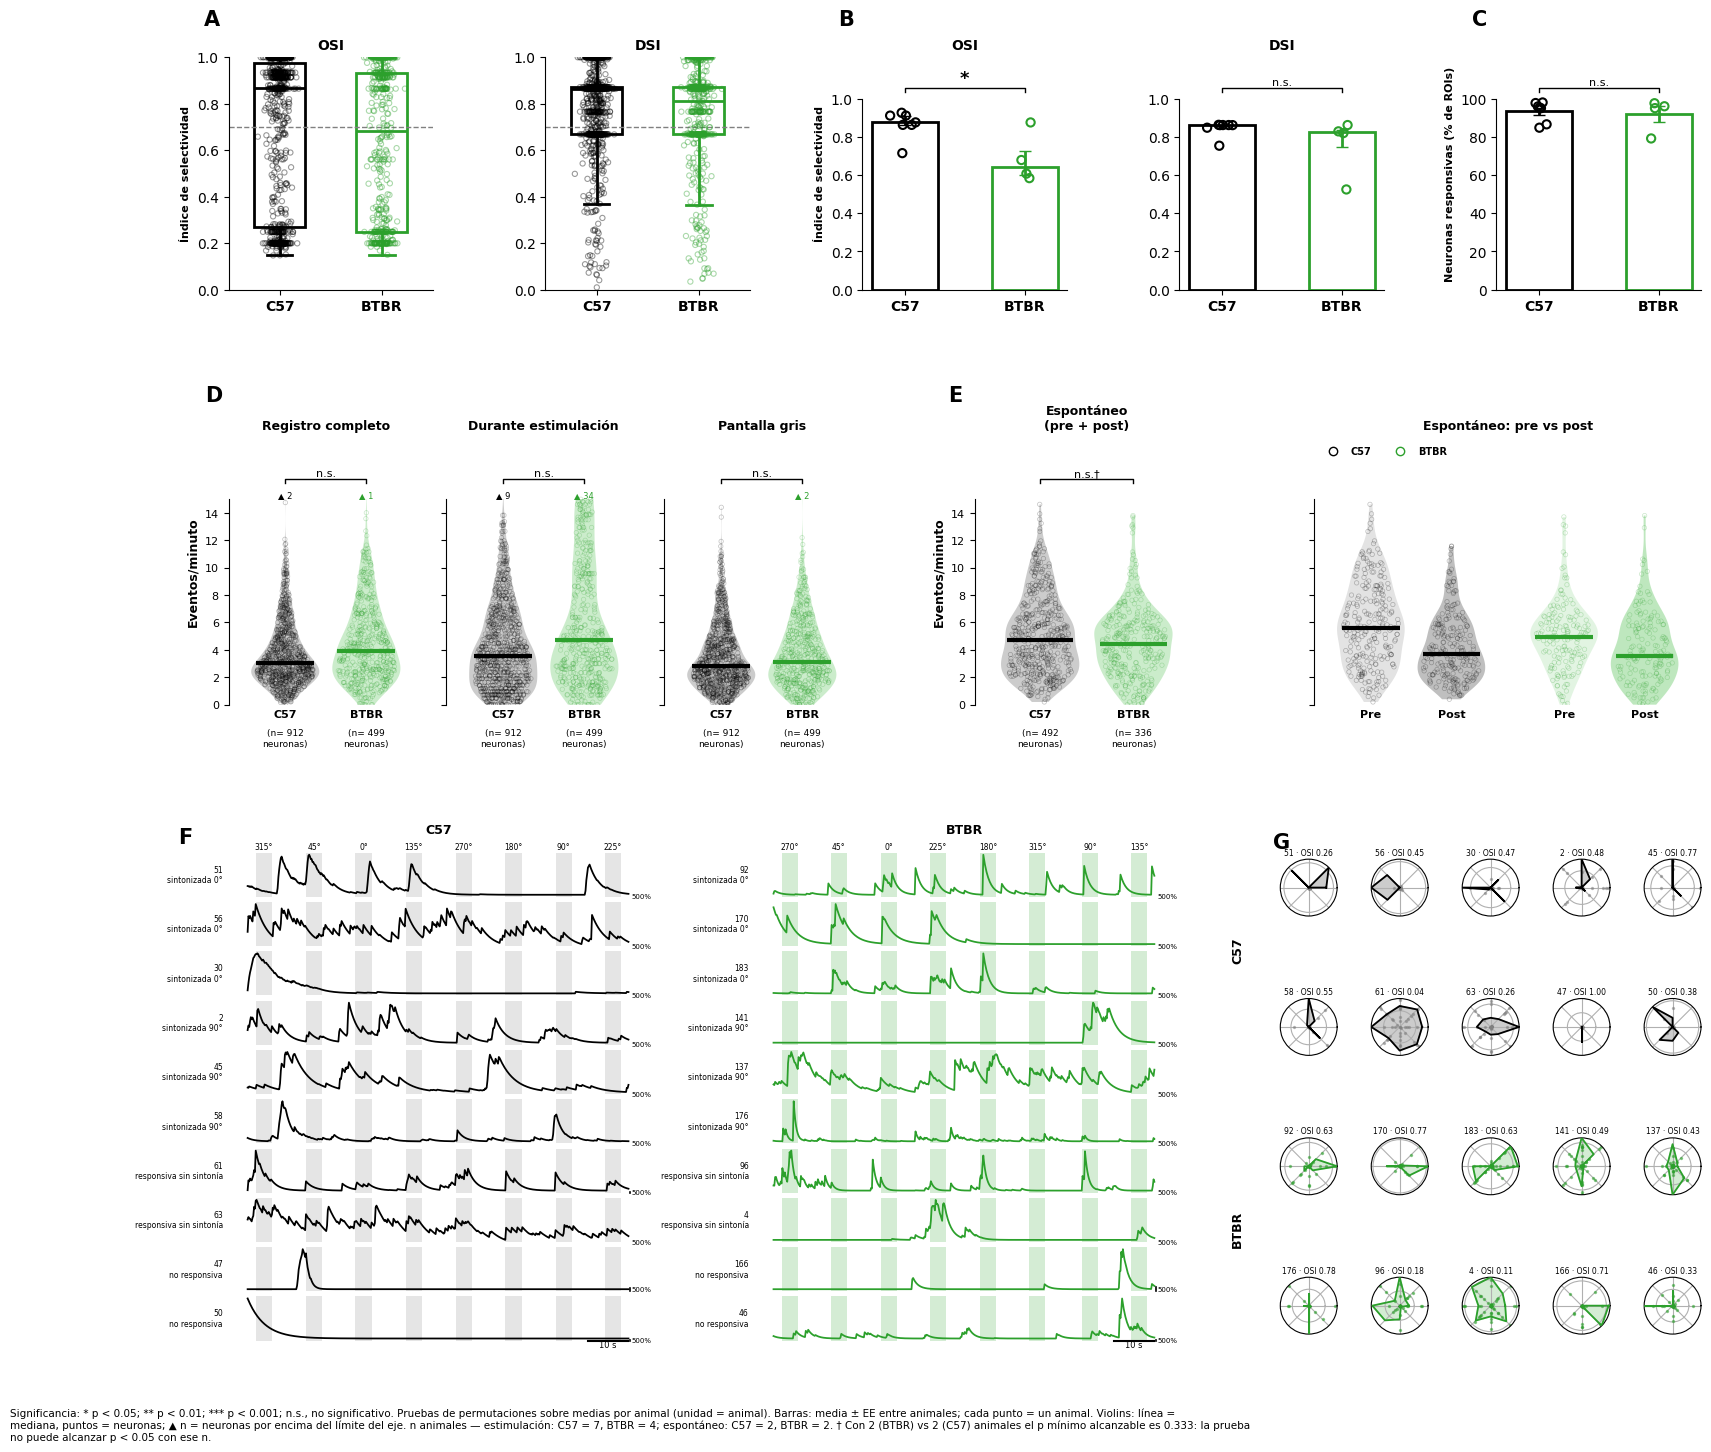

Spontaneous events/min — permutation tests on per-animal means
  BTBR vs C57, pre : p = 0.667  (n=2 vs 2 animals)
  BTBR vs C57, post: p = 1.000  (n=2 vs 2 animals)
  C57 pre vs post (paired, exact sign-flip): p = 0.500  (n=2 animals; smallest attainable p = 0.500)
  BTBR pre vs post (paired, exact sign-flip): p = 0.500  (n=2 animals; smallest attainable p = 0.500)


In [27]:
# ── Figure 1: all panels in one figure ────────────────────────────────────────
# Needs: summary_df, consolidated (section 8), permutation_test (section 10, fixed version),
#        session_data / animal_data, fig_rates + STYLE (events cell), select_examples / pick_block /
#        trial_responses / nice_bar / GENO_STYLE / constants (example-neurons cell), spon_df (spontaneous cell).
import textwrap
import matplotlib.pyplot as plt
from math import comb
from matplotlib.lines import Line2D
from itertools import product
from scipy.stats import gaussian_kde

GENOS       = ['C57', 'BTBR']
PAL         = {'C57': '#000000', 'BTBR': '#2ca02c'}
FIG_SIZE    = (19, 14.5)
YMAX        = 15          # events/min axis cut (shared by every events panel)
JITTER_FRAC = 0.83
LETTERS     = True
B           = 'bold' 
BAR_AGG     = 'median'    # panel B: value per animal = median (or mean) over its neurons
BAR_STAT    = 'median'    # panel B: bar and test use the median (or mean) across animals    # panel B: per-animal statistic over neurons ('median' or 'mean')     # weight for titles / axis labels / category labels
TAG_ES = {'non-responsive (spontaneous)': 'no responsiva', 'responsive, untuned': 'responsiva sin sintonía',
          'responsive, least tuned': 'responsiva, poco sintonizada'}
DAGGERS = set()           # filled while drawing: animal counts too small to ever reach p < 0.05


def swarm_violin(ax, x, vals, sty, rng, half_width=0.42, ymax=None, fill_alpha=0.4):
    """Filled violin + dots inside it + thick median. Density/median use all values; only <= ymax is drawn."""
    vals  = np.asarray(vals, float)
    hi    = vals.max() if ymax is None else min(vals.max(), ymax)
    shown = vals[vals <= hi]
    if len(vals) > 2 and np.ptp(vals) > 0 and vals.min() < hi:
        ys   = np.linspace(vals.min(), hi, 200)
        dens = gaussian_kde(vals)(ys)
        dens = dens / dens.max() * half_width
        ax.fill_betweenx(ys, x - dens, x + dens, facecolor=sty['fill'], alpha=fill_alpha, edgecolor='none', zorder=1)
        spread = np.interp(shown, ys, dens)
    else:
        spread = np.full(len(shown), 0.05)
    ax.scatter(x + rng.uniform(-1, 1, len(shown)) * spread * JITTER_FRAC, shown, s=10,
               facecolors='none', edgecolors=sty['dot'], linewidths=0.5, alpha=0.25, zorder=2)
    med = np.median(vals)
    if ymax is None or med <= ymax:
        ax.hlines(med, x - 0.85 * half_width, x + 0.85 * half_width, color=sty['line'], lw=3, zorder=4)
    else:
        ax.text(x, ymax, f'mediana {med:.1f}', ha='center', va='top', fontsize=6, color=sty['line'])
    if len(vals) - len(shown):
        ax.text(x, hi, f'▲ {len(vals) - len(shown)}', ha='center', va='bottom', fontsize=6, color=sty['line'])


# ── statistics: unit = animal ─────────────────────────────────────────────────
def signflip_test(diffs):
    """Exact paired test (sign flips of per-animal differences), two-tailed."""
    d   = np.asarray(diffs, float)
    obs = abs(d.mean())
    sgn = np.array(list(product([1, -1], repeat=len(d))))
    return float(np.mean(np.abs((sgn * d).mean(axis=1)) >= obs - 1e-12 * max(1.0, obs)))


def stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'


def permutation_test_stat(a, b, stat='median', max_exact=200_000, n_perm=20000, rng_seed=42):
    """Two-tailed permutation test on |stat(a) - stat(b)| (stat = 'median' or 'mean'); exact when feasible."""
    f    = np.median if stat == 'median' else np.mean
    a, b = np.asarray(a, float), np.asarray(b, float)
    allv = np.concatenate([a, b])
    n, N = len(a), len(a) + len(b)
    obs  = abs(f(a) - f(b))
    tol  = 1e-12 * max(1.0, obs)
    if comb(N, n) <= max_exact:
        cnt = tot = 0
        for idx in combinations(range(N), n):
            m = np.zeros(N, bool); m[list(idx)] = True
            cnt += abs(f(allv[m]) - f(allv[~m])) >= obs - tol
            tot += 1
        return cnt / tot
    rng, cnt = np.random.default_rng(rng_seed), 0
    for _ in range(n_perm):
        p = rng.permutation(allv)
        cnt += abs(f(p[:n]) - f(p[n:])) >= obs - tol
    return (cnt + 1) / (n_perm + 1)


def animal_test(df, col, agg='mean', stat='mean'):
    """BTBR vs C57. Value per animal = agg over its neurons; group statistic = stat across animals.
    Returns p and the smallest p this many animals can ever give."""
    am   = df.groupby(['genotype', 'animal_id'])[col].agg(agg).reset_index()
    b, c = (am.loc[am['genotype'] == g, col].values for g in ('BTBR', 'C57'))
    if len(b) < 2 or len(c) < 2:
        return None
    p = permutation_test(b, c) if stat == 'mean' else permutation_test_stat(b, c, stat)
    return {'p': p, 'nb': len(b), 'nc': len(c),
            'min_p': (2 if len(b) == len(c) else 1) / comb(len(b) + len(c), len(b))}


def bracket(ax, x0, x1, y, res, h):
    if res is None:
        return
    lab = stars(res['p'])
    sig = lab != 'n.s.'
    if res['min_p'] >= 0.05:                                   # this n can never reach p < 0.05
        lab += '†'
        DAGGERS.add((res['nb'], res['nc'], res['min_p']))
    ax.plot([x0, x0, x1, x1], [y - h, y, y, y - h], color='k', lw=1)
    ax.text((x0 + x1) / 2, y, lab, ha='center', va='bottom',
            fontsize=13 if sig else 8, fontweight=B if sig else 'normal')


def violin_axes(ax, positions, labels, first=True, ns=None):
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=8, fontweight=B)
    if ns is not None:                                         # n under each label, regular weight
        for x, t in zip(positions, ns):
            ax.text(x, -0.09, t, transform=ax.get_xaxis_transform(), ha='center', va='top', fontsize=6.5)
    ax.set_ylim(0, YMAX * 1.3)
    ax.set_yticks(np.arange(0, YMAX + 1, 2))
    ax.spines['left'].set_bounds(0, YMAX)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', labelleft=first, labelsize=8)


def letter(ax, s):
    if LETTERS:
        ax.text(-0.12, 1.12, s, transform=ax.transAxes, fontsize=15, fontweight=B, va='bottom')


def bar_axes(ax, top):
    ax.set_xticks(range(2)); ax.set_xticklabels(GENOS, fontweight=B)
    ax.set_ylim(0, top * 1.22)
    ax.set_yticks(np.linspace(0, top, 6))
    ax.spines['left'].set_bounds(0, top)
    ax.spines[['top', 'right']].set_visible(False)


# ── panel builders ────────────────────────────────────────────────────────────
def panel_pct(ax):
    rj = np.random.default_rng(0)
    for i, g in enumerate(GENOS):
        v = summary_df.loc[summary_df['genotype'] == g, 'pct_responsive'].values
        ax.bar(i, v.mean(), width=0.55, facecolor='none', edgecolor=PAL[g], linewidth=2)
        ax.errorbar(i, v.mean(), yerr=sem(v) if len(v) > 1 else 0, color=PAL[g], capsize=4, lw=2)
        ax.scatter(i + rj.normal(0, 0.05, len(v)), v, s=35, facecolors='none', edgecolors=PAL[g], linewidths=1.5, zorder=3)
    bar_axes(ax, 100)
    bracket(ax, 0, 1, 106, animal_test(summary_df.rename(columns={'pct_responsive': 'v'}), 'v'), 2)
    ax.set_ylabel('Neuronas responsivas (% de ROIs)', fontsize=8, fontweight=B)


def panel_box(ax, metric, ylabel=None):
    rj = np.random.default_rng(1)
    groups = [consolidated.loc[consolidated['genotype'] == g, metric].values for g in GENOS]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5, showfliers=False,
                    boxprops=dict(facecolor='none', linewidth=2), whiskerprops=dict(linewidth=2),
                    capprops=dict(linewidth=2), medianprops=dict(linewidth=2))
    for i, g in enumerate(GENOS):
        bp['boxes'][i].set_edgecolor(PAL[g]); bp['medians'][i].set_color(PAL[g])
        for k in ('whiskers', 'caps'):
            bp[k][2 * i].set_color(PAL[g]); bp[k][2 * i + 1].set_color(PAL[g])
        ax.scatter(rj.normal(i + 1, 0.06, len(groups[i])), groups[i], facecolors='none', edgecolors=PAL[g],
                   linewidths=0.8, s=14, alpha=0.4, zorder=3)
    ax.axhline(OSI_THRESH, ls='--', color='gray', lw=1)
    ax.set_xticks([1, 2]); ax.set_xticklabels(GENOS, fontweight=B)
    ax.set_ylim(0, 1); ax.set_title(metric, fontsize=10, fontweight=B)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=8, fontweight=B)
    ax.spines[['top', 'right']].set_visible(False)


def panel_bar(ax, metric):
    rj = np.random.default_rng(2)
    am = consolidated.groupby(['genotype', 'animal_id'])[metric].agg(BAR_AGG).reset_index()   # one value per animal
    for i, g in enumerate(GENOS):
        v = am.loc[am['genotype'] == g, metric].values
        if BAR_STAT == 'median':                                    # median across animals, IQR whiskers
            ctr, (q1, q3) = np.median(v), np.percentile(v, [25, 75])
            err = [[ctr - q1], [q3 - ctr]]
        else:                                                       # mean across animals, SEM whiskers
            ctr, err = v.mean(), (sem(v) if len(v) > 1 else 0)
        ax.bar(i, ctr, width=0.55, facecolor='none', edgecolor=PAL[g], linewidth=2)
        ax.errorbar(i, ctr, yerr=err, color=PAL[g], capsize=4, lw=2)
        ax.scatter(i + rj.normal(0, 0.05, len(v)), v, s=35, facecolors='none', edgecolors=PAL[g], linewidths=1.5, zorder=3)
    bar_axes(ax, 1.0)
    bracket(ax, 0, 1, 1.06, animal_test(consolidated, metric, agg=BAR_AGG, stat=BAR_STAT), 0.02)
    ax.set_title(metric, fontsize=10, fontweight=B)


def panel_events(ax, w, title, first):
    rg  = np.random.default_rng({'total': 10, 'stim': 11, 'gray': 12}[w])
    col = f'ev_min_{w}'
    for i, g in enumerate(GENOS):
        swarm_violin(ax, i, fig_rates.loc[fig_rates['genotype'] == g, col].values, STYLE[g], rg, ymax=YMAX)
    bracket(ax, 0, 1, YMAX * 1.10, animal_test(fig_rates, col), YMAX * 0.02)
    n = fig_rates['genotype'].value_counts()
    violin_axes(ax, [0, 1], GENOS, first, [f'(n= {n[g]}\nneuronas)' for g in GENOS])
    ax.set_xlim(-0.7, 1.7); ax.set_title(title, fontsize=9, fontweight=B)
    if first:
        ax.set_ylabel('Eventos/minuto', fontsize=9, fontweight=B)


def panel_spont_global(ax):
    rg = np.random.default_rng(20)
    for i, g in enumerate(GENOS):
        swarm_violin(ax, i, spon_df.loc[spon_df['genotype'] == g, 'ev_min'].values, STYLE[g], rg, ymax=YMAX)
    bracket(ax, 0, 1, YMAX * 1.10, animal_test(spon_df.rename(columns={'ev_min': 'v'}), 'v'), YMAX * 0.02)
    n = spon_df['genotype'].value_counts()
    violin_axes(ax, [0, 1], GENOS, True, [f'(n= {n[g]}\nneuronas)' for g in GENOS])
    ax.set_xlim(-0.7, 1.7); ax.set_title('Espontáneo\n(pre + post)', fontsize=9, fontweight=B)
    ax.set_ylabel('Eventos/minuto', fontsize=9, fontweight=B)


def panel_spont_prepost(ax):
    rg  = np.random.default_rng(21)
    pos = {('C57', 'pre'): 0, ('C57', 'post'): 1, ('BTBR', 'pre'): 2.4, ('BTBR', 'post'): 3.4}
    for (g, cond), x in pos.items():
        v = spon_df.loc[(spon_df['genotype'] == g) & (spon_df['condition'] == cond), 'ev_min'].values
        if len(v):
            swarm_violin(ax, x, v, STYLE[g], rg, ymax=YMAX, fill_alpha=0.22 if cond == 'pre' else 0.5)
    violin_axes(ax, list(pos.values()), ['Pre', 'Post', 'Pre', 'Post'], False)
    ax.set_xlim(-0.7, 4.1); ax.set_title('Espontáneo: pre vs post', fontsize=9, fontweight=B)
    ax.legend(handles=[Line2D([0], [0], marker='o', mfc='none', mec=PAL[g], ls='', label=g) for g in GENOS],
              frameon=False, loc='upper left', fontsize=7, ncol=2, prop={'weight': B, 'size': 7})


def panel_traces(spec, aid, info, blk, blk_angles):
    dff = session_data[aid]['dff']
    geno = session_data[aid]['genotype']
    T, st  = len(dff), GENO_STYLE[geno]
    pad    = int(PAD_S * SAMPLING_RATE)
    a0, a1 = max(0, blk[0] - pad), min(T, blk[-1] + STIM_FRAMES + pad)
    t      = np.arange(a0, a1) / SAMPLING_RATE
    tr     = np.array([dff[a0:a1, d['neuron']] for d in info])
    spans  = tr.max(axis=1) - tr.min(axis=1)
    sub    = spec.subgridspec(len(info), 1, hspace=0.12)
    axes   = []
    for r, (d, y, sp_) in enumerate(zip(info, tr, spans)):
        ax = fig.add_subplot(sub[r], sharex=axes[0] if axes else None)
        axes.append(ax)
        for o in blk:
            ax.axvspan(o / SAMPLING_RATE, (o + STIM_FRAMES) / SAMPLING_RATE, color=st['shade'], alpha=st['alpha'], lw=0)
        ax.plot(t, y, color=st['trace'], lw=TRACE_LW * 0.8)
        ax.set_ylim(y.min() - 0.05 * sp_, y.min() + 1.05 * sp_)
        tag = TAG_ES.get(d['tag'], d['tag'].replace('tuned', 'sintonizada'))
        ax.set_ylabel(f"{d['neuron']}\n{tag}", rotation=0, ha='right', va='center', fontsize=5.5)
        ax.set_xticks([]); ax.set_yticks([])
        for spn in ax.spines.values():
            spn.set_visible(False)
        b, lo = nice_bar(sp_), ax.get_ylim()[0]
        ax.plot([t[-1] + 0.4] * 2, [lo, lo + b], 'k', lw=1.2, clip_on=False)
        ax.text(t[-1] + 0.8, lo + b / 2, f'{b * 100:.0f}%', fontsize=5, va='center')
    if SHOW_ANGLE_LABELS:
        for o, a in zip(blk, blk_angles):
            axes[0].text((o + STIM_FRAMES / 2) / SAMPLING_RATE, 1.03, f'{a}°',
                         transform=axes[0].get_xaxis_transform(), ha='center', va='bottom', fontsize=5.5)
    ylo = axes[-1].get_ylim()[0]
    axes[-1].plot([t[-1] - 10, t[-1]], [ylo, ylo], 'k', lw=1.5, clip_on=False)
    axes[-1].text(t[-1] - 5, ylo, '10 s', ha='center', va='top', fontsize=6)
    axes[0].set_title(geno, fontsize=9, fontweight=B, pad=14)          # genotype only, no animal ID
    return axes[0]


def panel_polar(spec, entries):
    sub = spec.subgridspec(2 * len(entries), 5, hspace=1.0, wspace=0.6)
    first = None
    for k, (aid, info) in enumerate(entries):
        s    = session_data[aid]
        tr   = trial_responses(s['dff'], s['onsets_by_angle'])
        angs = sorted(tr)
        th   = np.deg2rad(angs + [angs[0]])
        st   = GENO_STYLE[s['genotype']]
        for j, d in enumerate(info):
            ax = fig.add_subplot(sub[2 * k + j // 5, j % 5], projection='polar')
            first = first or ax
            if j == 0:                                                 # genotype label for this block of rows
                ax.text(-0.75, -0.6, s['genotype'], transform=ax.transAxes, rotation=90, ha='center',
                        va='center', fontsize=9, fontweight=B)
            n    = d['neuron']
            mean = np.clip([tr[a][:, n].mean() for a in angs], 0, None)
            for a in angs:
                ax.scatter(np.full(len(tr[a]), np.deg2rad(a)), np.clip(tr[a][:, n], 0, None),
                           s=2, color=st['shade'], alpha=0.5, zorder=2)
            ax.plot(th, np.append(mean, mean[0]), color=st['trace'], lw=1.3, zorder=3)
            ax.fill(th, np.append(mean, mean[0]), color=st['trace'], alpha=0.2, zorder=1)
            ax.set_xticks(np.deg2rad(angs)); ax.set_xticklabels([])
            ax.set_ylim(0, max(mean.max(), R_MIN)); ax.set_yticklabels([])
            ax.tick_params(pad=-2)
            ax.set_title(f"{n} · OSI {d['osi_vec']:.2f}", fontsize=5.5, pad=3)
    return first


# ── assemble ──────────────────────────────────────────────────────────────────
entries = []
for g in GENOS:
    aid = EXAMPLE_ANIMAL.get(g) or next(a for a, d in session_data.items() if d['genotype'] == g)
    blk, blk_angles = pick_block(aid)
    entries.append((aid, select_examples(aid, blk, blk_angles), blk, blk_angles))

DAGGERS.clear()
fig   = plt.figure(figsize=FIG_SIZE)
outer = fig.add_gridspec(3, 1, height_ratios=[1, 1.15, 2.1], hspace=0.45, top=0.96, bottom=0.075)

row1 = outer[0].subgridspec(1, 5, wspace=0.55)
axA1 = fig.add_subplot(row1[0]); panel_box(axA1, 'OSI', 'Índice de selectividad')     # A: neurons (median, IQR)
axA2 = fig.add_subplot(row1[1]); panel_box(axA2, 'DSI')
axB1 = fig.add_subplot(row1[2]); panel_bar(axB1, 'OSI')                                # B: animals (mean ± SEM, test)
axB2 = fig.add_subplot(row1[3], sharey=axB1); panel_bar(axB2, 'DSI')
axB1.set_ylabel('Índice de selectividad', fontsize=8, fontweight=B)
axC  = fig.add_subplot(row1[4]); panel_pct(axC)                                        # C: % responsive neurons
for a_, s_ in ((axA1, 'A'), (axB1, 'B'), (axC, 'C')):
    letter(a_, s_)

row2 = outer[1].subgridspec(1, 3, width_ratios=[3.1, 1.1, 1.9], wspace=0.28)
ev   = row2[0].subgridspec(1, 3, wspace=0.12)
axE  = []
for k, (w, ttl) in enumerate([('total', 'Registro completo'), ('stim', 'Durante estimulación'), ('gray', 'Pantalla gris')]):
    ax = fig.add_subplot(ev[k], sharey=axE[0] if axE else None)
    panel_events(ax, w, ttl, first=(k == 0)); axE.append(ax)
letter(axE[0], 'D')
axS1 = fig.add_subplot(row2[1], sharey=axE[0]); panel_spont_global(axS1)
axS2 = fig.add_subplot(row2[2], sharey=axE[0]); panel_spont_prepost(axS2)
letter(axS1, 'E')

row3 = outer[2].subgridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.25)
axF  = panel_traces(row3[0], *entries[0]); letter(axF, 'F')
panel_traces(row3[1], *entries[1])
axG  = panel_polar(row3[2], [(e[0], e[1]) for e in entries]); letter(axG, 'G')

# ── footnote: significance key, unit of analysis, n animals ───────────────────
n_stim = summary_df['genotype'].value_counts()
n_spon = spon_df.groupby('genotype')['animal_id'].nunique()
note = ('Significancia: * p < 0.05; ** p < 0.01; *** p < 0.001; n.s., no significativo. Pruebas de permutaciones '
        'sobre medias por animal (unidad = animal). Barras: media ± EE entre animales; cada punto = un animal. '
        'Violins: línea = mediana, puntos = neuronas; ▲ n = neuronas por encima del límite del eje. '
        f'n animales — estimulación: C57 = {n_stim.get("C57", 0)}, BTBR = {n_stim.get("BTBR", 0)}; '
        f'espontáneo: C57 = {n_spon.get("C57", 0)}, BTBR = {n_spon.get("BTBR", 0)}.')
for nb, nc, mp in sorted(DAGGERS):
    note += (f' † Con {nb} (BTBR) vs {nc} (C57) animales el p mínimo alcanzable es {mp:.3f}: '
             'la prueba no puede alcanzar p < 0.05 con ese n.')
fig.text(0.01, 0.005, textwrap.fill(note, 230), fontsize=7.5, va='bottom', ha='left')

fig.savefig(OUTPUT_DIR / 'figura1_composite.svg', format='svg', bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'figura1_composite.png', dpi=200, bbox_inches='tight')
plt.show()

# ── tests behind the spontaneous panels (unit = animal) ───────────────────────
sm = spon_df.groupby(['genotype', 'animal_id', 'condition'])['ev_min'].mean().unstack('condition').reset_index()
print('Spontaneous events/min — permutation tests on per-animal means')
for cond in ('pre', 'post'):
    b, c = (sm.loc[sm['genotype'] == g, cond].dropna().values for g in ('BTBR', 'C57'))
    if len(b) >= 2 and len(c) >= 2:
        print(f'  BTBR vs C57, {cond:4s}: p = {permutation_test(b, c):.3f}  (n={len(b)} vs {len(c)} animals)')
for g in GENOS:
    pp = sm.loc[sm['genotype'] == g].dropna(subset=['pre', 'post'])
    if len(pp) >= 2:
        print(f'  {g} pre vs post (paired, exact sign-flip): p = {signflip_test(pp["post"] - pp["pre"]):.3f}  '
              f'(n={len(pp)} animals; smallest attainable p = {2 / 2 ** len(pp):.3f})')

note = ('Significancia: * p < 0.05; ** p < 0.01; *** p < 0.001; n.s., no significativo. Pruebas de permutaciones '
        'sobre valores por animal (unidad = animal). Barras en B: mediana entre animales y rango intercuartílico, cada punto = mediana de las neuronas de un animal, '
        'prueba sobre la diferencia de medianas; barras en C: media ± EE entre animales. '
        'Violins: línea = mediana, puntos = neuronas; ▲ n = neuronas por encima del límite del eje. '
        f'n animales — estimulación: C57 = {n_stim.get("C57", 0)}, BTBR = {n_stim.get("BTBR", 0)}; '
        f'espontáneo: C57 = {n_spon.get("C57", 0)}, BTBR = {n_spon.get("BTBR", 0)}.')

,C57,BTBR,diff,diff_lo,diff_hi,rel_%,rel_lo,rel_hi,n_C57,n_BTBR,note
window,,,,,,,,,,,
Espontáneo pre,5.70,5.05,-0.65,-1.72,0.49,-11.39,-28.50,9.14,2,2,CI unreliable: < 3 animals in a group
Espontáneo post,4.26,3.96,-0.30,-1.11,0.50,-7.05,-24.54,12.23,2,2,CI unreliable: < 3 animals in a group
Espontáneo pre + post,4.99,4.50,-0.49,-1.22,0.28,-9.82,-23.63,5.95,2,2,CI unreliable: < 3 animals in a group
Registro completo,3.89,4.05,0.16,-1.21,1.72,4.04,-29.64,47.09,7,4,few animals: CI likely too narrow
Durante estimulación,4.61,5.60,0.99,-1.54,3.64,21.36,-31.66,88.25,7,4,few animals: CI likely too narrow
Pantalla gris,3.62,3.40,-0.22,-1.30,1.03,-6.20,-32.31,30.97,7,4,few animals: CI likely too narrow


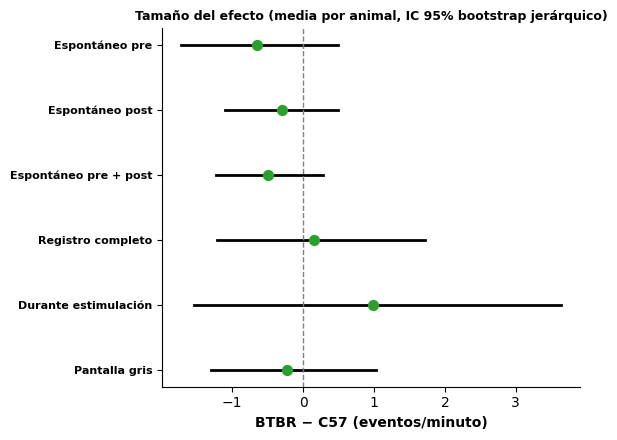

In [25]:
# ── Effect size of the BTBR − C57 difference in events/min (unit = animal) ────
# Hierarchical bootstrap: resample animals within each genotype, then resample each chosen animal's neurons.
# Group value = mean of the per-animal means (every animal weighs the same).
# Needs spon_df (spontaneous cell) and fig_rates (events cell).
import matplotlib.pyplot as plt

N_BOOT = 10000
CI     = 95


def hier_boot_diff(df, col, n_boot=N_BOOT, seed=0):
    rng = np.random.default_rng(seed)
    grp = {g: [d[col].values for _, d in df[df['genotype'] == g].groupby('animal_id')] for g in ('BTBR', 'C57')}
    if min(len(v) for v in grp.values()) < 2:
        return None
    obs_b, obs_c = (np.mean([a.mean() for a in grp[g]]) for g in ('BTBR', 'C57'))
    diffs, rels  = np.empty(n_boot), np.empty(n_boot)
    for i in range(n_boot):
        m = {}
        for g, animals in grp.items():
            pick = rng.integers(0, len(animals), len(animals))                    # animals with replacement
            m[g] = np.mean([animals[k][rng.integers(0, len(animals[k]), len(animals[k]))].mean()
                            for k in pick])                                       # neurons with replacement
        diffs[i], rels[i] = m['BTBR'] - m['C57'], 100 * (m['BTBR'] - m['C57']) / m['C57']
    lo, hi = (100 - CI) / 2, 100 - (100 - CI) / 2
    return {'C57': obs_c, 'BTBR': obs_b, 'diff': obs_b - obs_c,
            'diff_lo': np.percentile(diffs, lo), 'diff_hi': np.percentile(diffs, hi),
            'rel_%': 100 * (obs_b - obs_c) / obs_c,
            'rel_lo': np.nanpercentile(rels, lo), 'rel_hi': np.nanpercentile(rels, hi),
            'n_BTBR': len(grp['BTBR']), 'n_C57': len(grp['C57'])}


tasks = [('Espontáneo pre',       spon_df[spon_df['condition'] == 'pre'],  'ev_min'),
         ('Espontáneo post',      spon_df[spon_df['condition'] == 'post'], 'ev_min'),
         ('Espontáneo pre + post', spon_df,                                'ev_min'),
         ('Registro completo',    fig_rates,                               'ev_min_total'),
         ('Durante estimulación', fig_rates,                               'ev_min_stim'),
         ('Pantalla gris',        fig_rates,                               'ev_min_gray')]

rows = []
for name, df, col in tasks:
    r = hier_boot_diff(df, col)
    if r is None:
        print(f'{name}: fewer than 2 animals in a genotype, skipped')
        continue
    r['window'] = name
    n_min = min(r['n_BTBR'], r['n_C57'])
    r['note'] = ('CI unreliable: < 3 animals in a group' if n_min < 3 else
                 'few animals: CI likely too narrow' if n_min < 5 else '')
    rows.append(r)
eff = pd.DataFrame(rows).set_index('window')
eff.to_csv(OUTPUT_DIR / 'effect_size_events_per_min.csv')
display(eff[['C57', 'BTBR', 'diff', 'diff_lo', 'diff_hi', 'rel_%', 'rel_lo', 'rel_hi', 'n_C57', 'n_BTBR', 'note']].round(2))

# Forest plot: BTBR − C57 (events/min) with 95 % CI
fig, ax = plt.subplots(figsize=(6, 0.55 * len(eff) + 1.2))
for i, (name, r) in enumerate(eff.iterrows()):
    ax.plot([r['diff_lo'], r['diff_hi']], [i, i], color='k', lw=2)
    ax.scatter(r['diff'], i, color='#2ca02c', s=50, zorder=3)
ax.axvline(0, color='gray', ls='--', lw=1)
ax.set_yticks(range(len(eff))); ax.set_yticklabels(eff.index, fontweight='bold', fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('BTBR − C57 (eventos/minuto)', fontweight='bold')
ax.set_title(f'Tamaño del efecto (media por animal, IC {CI}% bootstrap jerárquico)', fontweight='bold', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'effect_size_events_per_min.svg', format='svg', bbox_inches='tight')
plt.show()

In [26]:
# ── Does the GMM readout depend on preferred angle? ───────────────────────────
c = consolidated.copy()
c['pref_bin'] = ((c['pref_angle'] / 45).round() % 8 * 45).astype(int)
g = c.groupby(['genotype', 'pref_bin'])
display(g[['OSI', 'DSI', 'circ_var']].mean().round(3).join(g.size().rename('n')))

OSI    DSI  circ_var    n
genotype pref_bin                             
BTBR     0         0.969  0.924     0.236   50
         45        0.765  0.431     0.754   20
         90        0.657  0.753     0.489   81
         135       0.417  0.775     0.146  136
         180       0.482  0.773     0.137   95
         225       0.941  0.722     0.296   47
         270       0.804  0.519     0.686   21
         315       0.558  0.422     0.859   15
C57      0         0.980  0.946     0.249  140
         45        0.783  0.630     0.616   38
         90        0.806  0.771     0.240  125
         135       0.429  0.759     0.156  242
         180       0.616  0.777     0.149  165
         225       0.905  0.768     0.270   88
         270       0.880  0.506     0.688   33
         315       0.495  0.598     0.639    8